## Predicting Road Collision Severity in London: Integrating Network Centrality, Traffic Speed, and Deprivation (2020–2024)
### A Machine Learning Approach toward Predicting Accident Severity

---
> **Author:** [Your Name]  
> **Date:** [Date]  
> **Module:** [Module Code / Name]

---
## 1. Introduction

Road traffic collisions are a leading cause of preventable death and serious injury in urban environments. In London, despite a Vision Zero strategy targeting a 70% reduction in Killed or Seriously Injured (KSI) casualties by 2030, approximately 3,700 people were killed or seriously injured on the capital's roads in 2023 — pedestrians and cyclists accounting for nearly 60% of all KSI (TfL, 2024). KSI, defined within STATS19 as fatalities and injuries involving fracture, concussion, internal trauma, or inpatient hospitalisation, represents the most policy-critical end of the severity spectrum. Understanding *which* collisions result in KSI outcomes has direct implications for infrastructure investment, emergency resource allocation, and targeted safety intervention.

The determinants of KSI risk are multi-dimensional. Speed limit, lighting, road surface, and junction characteristics consistently emerge as primary severity predictors in ensemble modelling studies on STATS19 data (Kaur & Bhatt, 2025). Deprivation compounds this: pedestrians in the most deprived neighbourhoods face up to three times the KSI probability of those in least deprived areas, reflecting poorer crossing provision and lower vehicle safety standards (Smith et al., 2019). Critically, Sarkar, Webster & Kumari (2018) demonstrated in a five-year Greater London study that street network topology — specifically betweenness centrality, divergence ratio, and hull radius — is independently associated with KSI odds alongside speed and deprivation, establishing that a location's structural position within the road network shapes severity outcomes. Nippani et al. (2023) corroborate this at scale, showing graph-based representations improve crash prediction performance across large road networks.

This study combines OpenStreetMap-derived centrality measures with STATS19 records, the Index of Multiple Deprivation, DfT AADF traffic counts, and LAEI 2022 road speed data to predict binary KSI outcomes across London (2020–2024). Three tree-based classifiers are evaluated under stratified cross-validation with SMOTE oversampling, and model decisions interpreted with SHAP (Lundberg & Lee, 2017) to surface the network, socioeconomic, and environmental drivers of collision severity.

**References:**
- Sarkar, C., Webster, C. & Kumari, S. (2018). Street morphology and severity of road casualties: A 5-year study of Greater London. *International Journal of Sustainable Transportation*, 12(7), 510–525. https://doi.org/10.1080/15568318.2017.1402972
- Kaur, R. & Bhatt, U. (2025). Non-linear determinants of pedestrian injury severity: Evidence from administrative data in Great Britain. *arXiv preprint* arXiv:2512.04022.
- Smith, N. et al. (2019). Socioeconomic inequalities in child pedestrian casualties: Evidence from England. *Journal of Transport & Health*, 12, 113–122.
- Nippani, A., Li, D., Ju, H., Koutsopoulos, H.N. & Zhang, H.R. (2023). Graph neural networks for road safety modeling: datasets and evaluations for accident analysis. *Advances in Neural Information Processing Systems (NeurIPS)*, 36.
- Lundberg, S.M. & Lee, S.I. (2017). A unified approach to interpreting model predictions. *Advances in Neural Information Processing Systems (NIPS)*, 30, 4766–4777.
- Transport for London (2024). *Casualties in Greater London 2023: Data Release*. TfL.

---
## 2. Research Question

**Primary:** To what extent do graph-derived network centrality measures, multi-dimensional deprivation indicators, and casualty-level vulnerability factors jointly predict KSI outcomes in London road collisions (2020–2024), and which feature group contributes the most explanatory power?

**Sub-questions:**

- **Network structure:** Do closeness and betweenness centrality independently predict elevated KSI risk after controlling for traffic volume, speed, and road environment — and does including graph features measurably improve model performance?

- **Deprivation:** Which aspects of deprivation — area-level, driver, or casualty — most strongly shape KSI severity outcomes?

- **Casualty vulnerability:** How do casualty characteristics — mode of travel, age group, and collision complexity — shape KSI probability?

---
## 3. Data

### 3.1 Data Sources

Seven datasets were integrated to construct the analytical feature matrix. 

| Dataset | Source | Spatial Coverage | Temporal Coverage |
|---|---|---|---|
| STATS19 — Collisions | DfT / data.gov.uk | England & Wales | 2020–2024 |
| STATS19 — Vehicles | DfT / data.gov.uk | England & Wales | 2020–2024 |
| STATS19 — Casualties | DfT / data.gov.uk | England & Wales | 2020–2024 |
| London Road Network | OpenStreetMap via OSMnx | Greater London | Current |
| Index of Multiple Deprivation 2019 | MHCLG / data.gov.uk | England (LSOA) | 2019 |
| Traffic Count Points & AADF | DfT / roadtraffic.dft.gov.uk | Great Britain | 2000–2024 |
| LAEI 2022 — Road Speeds (Major & Minor) | GLA / data.london.gov.uk | Greater London | 2022 |


### 3.2 Data Preparation

**STATS19 filtering and aggregation.** The dataset was spatially filtered to Greater London, then aggregated from vehicle/casualty to collision level. Continuous fields were summarised as means and minimums while categorical fields become binary involvement flags. The binary KSI target variable is constructed by collapsing STATS19 severity codes 1 (Fatal) and 2 (Serious) into a single positive class, with code 3 (Slight) forming the negative class, consistent with the standard KSI definition used in UK road safety reporting (TfL, 2024)

**Graph-based network measures.** Node-level centrality measures, betweenness centrality and closeness centrality were computed using NetworkX across the full network. Each collision was spatially snapped to its nearest network node, and the corresponding centrality values joined to the collision record. Betweenness centrality captures a node's role as a thoroughfare in the network, while closeness centrality reflects how quickly a location can be reached from all other nodes. 

**Traffic volume.** Each collision was matched to its nearest DfT traffic count point within 1,000 m. Site-mean AADF values were computed across 2020–2024 to align with the study period. Total motor vehicle flow was log-transformed to correct for strong right skew.

**Road speed proxy.** STATS19 records the posted speed limit and vehicle manoeuvre at the time of collision, but does not record actual vehicle speed at impact. To address this gap, average operating speed was approximated using LAEI 2022 modelled speed. Temporal features — hour of collision and time period (AM peak, inter-peak, PM peak, night) were included to capture time-of-day variation in operating speeds. OS National Geographic Database ITN (Integrated Transport Network) data includes routable speed attributes at link level and would provide a more direct speed proxy. However, access is restricted to licensed users ([OS NGD Transport Network](https://www.ordnancesurvey.co.uk/products/os-ngd-api-features/transport)).

**Deprivation.** IMD 2019 deciles were joined to collision records in three distinct forms capturing a different dimension of socioeconomic context: area-level deprivation (`imd_decile`, the LSOA of the accident location), driver deprivation (`mean_driver_imd`), and casualty deprivation (`mean_casualty_imd`).

### 3.3 Variables Selected for Analysis

The final analytical feature set comprises 39 variables across seven groups. The binary KSI outcome (`severity_binary`: 1 = Fatal/Serious, 0 = Slight) is the target variable throughout.

**Target variable**

| Variable | Type | Definition |
|---|---|---|
| `severity_binary` | Binary | 1 = KSI (Fatal or Serious); 0 = Slight. Derived from STATS19 `collision_severity` codes 1 and 2. |

**Graph centrality (3)**

| Variable | Type | Definition |
|---|---|---|
| `closeness_centrality` | Continuous | Reciprocal of mean shortest-path distance from node to all others; reflects network accessibility. |
| `betweenness_centrality` | Continuous | Proportion of all shortest paths passing through a node; reflects throughput load and conflict potential. |
| `degree_centrality` | Continuous | Number of edges connected to a node, normalised by maximum possible; reflects junction complexity. |

**Temporal (2)**

| Variable | Type | Definition |
|---|---|---|
| `hour_of_collision` | Integer | Hour of day (0–23); proxy for prevailing operating speeds and traffic state. |
| `time_period_enc` | Ordinal | AM peak / inter-peak / PM peak / night; captures systematic temporal severity patterns. |

**Collision environment (8)**

| Variable | Type | Definition |
|---|---|---|
| `speed_limit` | Ordinal | Posted speed limit in mph (20–70). |
| `road_type` | Categorical | Motorway, A-road, B-road, unclassified, etc. |
| `junction_detail` | Categorical | T-junction, crossroads, roundabout, slip road, etc. |
| `junction_control` | Categorical | Traffic signals, give way, stop, uncontrolled. |
| `light_conditions` | Categorical | Daylight, darkness (lit / unlit / unknown lighting). |
| `weather_conditions` | Categorical | Fine, rain, snow, fog, high winds, etc. |
| `road_surface_conditions` | Categorical | Dry, wet, frost/ice, flood. |
| `pedestrian_crossing` | Categorical | Crossing facility type within 50 m of collision. |

**Deprivation — three dimensions (3)**

| Variable | Type | Definition |
|---|---|---|
| `imd_decile` | Ordinal | IMD 2019 decile of accident LSOA (1 = most deprived); captures road environment quality. |
| `mean_driver_imd` | Continuous | Mean IMD decile of drivers' home postcodes per collision; proxy for vehicle quality and risk behaviour. |
| `mean_casualty_imd` | Continuous | Mean IMD decile of casualties' home postcodes per collision; proxy for individual vulnerability. |

**Vehicle-level aggregates (12)**

| Variable | Type | Definition |
|---|---|---|
| `motorcycle_involved` | Binary | Any motorcycle or moped involved. |
| `hgv_involved` | Binary | Any heavy goods vehicle involved. |
| `cycle_involved` | Binary | Any pedal cycle involved. |
| `any_skid_overturn` | Binary | Any vehicle skidded or overturned. |
| `any_hit_offroad_object` | Binary | Any vehicle struck an off-road object (roadside barrier, tree, sign, etc.). |
| `any_left_carriageway` | Binary | Any vehicle left the carriageway. |
| `any_front_impact` | Binary | Any vehicle had a front-impact collision (head-on or rear-end). |
| `any_moving_vehicle` | Binary | At least one vehicle was moving at point of impact (vs. stationary). |
| `any_turning_vehicle` | Binary | At least one vehicle was executing a turn at point of impact. |
| `work_journey` | Binary | Any driver making a work or business journey at time of collision. |
| `mean_driver_age` | Continuous | Mean age of all drivers involved per collision. |
| `any_male_driver` | Binary | Any male driver involved; used as a risk behaviour proxy. |

**Casualty-level aggregates (8)**

| Variable | Type | Definition |
|---|---|---|
| `pedestrian_casualty` | Binary | At least one pedestrian casualty. |
| `motorcyclist_casualty` | Binary | At least one motorcyclist casualty. |
| `cyclist_casualty` | Binary | At least one cyclist casualty. |
| `child_casualty` | Binary | At least one casualty aged under 16. |
| `elderly_casualty` | Binary | At least one casualty aged 70 or over. |
| `min_casualty_age` | Integer | Age of youngest casualty; captures child involvement continuously. |
| `ped_on_crossing` | Binary | Pedestrian struck while on or near a marked crossing. |
| `n_casualties` | Integer | Total number of casualties per collision; measures collision severity scale. |

**Traffic volume and speed (3)**

| Variable | Type | Definition |
|---|---|---|
| `aadf_log` | Continuous | Log-transformed total annual average daily motor vehicle flow at nearest count point. |
| `accident_rate_clipped` | Continuous | Accidents per million vehicle-days at nearest count point (99th-percentile clipped). |
| `avg_speed_kph` | Continuous | LAEI 2022 average operating speed: major-road link speed (≤30 m match) or minor-road 1 km² grid fallback. |

### 3.4 Data Quality and Completeness

The table below summarises record counts and completeness at each stage of the data integration pipeline.

| Stage | Records | Notes |
|---|---|---|
| STATS19 national (2020–2024) | ~1,900,000 | England & Wales, all severities |
| Filtered to Greater London boundary | 109,024 | Point-in-polygon clip to GLA boundary |
| LAEI road speed assigned | 109,023 | 99.99% coverage; 1 record unmatched |
| AADF-matched (≤1,000 m count point) | 103,759 | 95.2% of London collisions |
| After feature dropna (final model) | 103,740 | 19 records dropped; 99.98% retention |
| — of which KSI (positive class) | ~16,391 | 15.8% KSI rate |
| — of which Slight (negative class) | ~87,349 | 84.2% slight rate |
| Training set (70%) | 72,618 | Stratified split; class balance preserved |
| Held-out test set (30%) | 31,122 | Stratified split; never used during training |

Overall data loss from national dataset to final model is driven primarily by the AADF spatial join: the 4.8% of London collisions beyond 1,000 m of a DfT count point are excluded from the modelling sample. These records are concentrated in outer and rural-fringe boroughs where the count point network is sparser, introducing a mild spatial selection bias toward inner and mid-London collisions. This should be acknowledged as a limitation when generalising findings to outer-borough locations on unmonitored roads. Missing values after AADF matching are negligible (19 records, <0.02%), indicating that the joined feature set is near-complete for the retained sample.

In [1]:
# 3. DATA LOADING & PREPROCESSING 
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
from pathlib import Path
import urllib.request
warnings.filterwarnings('ignore')

# ── 3.1 Load all three STATS19 tables (5-year files) 
# Source: https://www.gov.uk/government/statistical-data-sets/road-safety-open-data
RAW_DIR  = Path('large')   
CACHE_DIR = Path('data')   

RAW_DIR.mkdir(exist_ok=True)
CACHE_DIR.mkdir(exist_ok=True)

TABLES = {
    'collisions': {
        'url':     'https://data.dft.gov.uk/road-accidents-safety-data/'
                   'dft-road-casualty-statistics-collision-last-5-years.csv',
        'raw':     RAW_DIR  / 'dft-road-casualty-statistics-collision-last-5-years.csv',
        'parquet': CACHE_DIR / 'collisions.parquet',
    },
    'vehicles': {
        'url':     'https://data.dft.gov.uk/road-accidents-safety-data/'
                   'dft-road-casualty-statistics-vehicle-last-5-years.csv',
        'raw':     RAW_DIR  / 'dft-road-casualty-statistics-vehicle-last-5-years.csv',
        'parquet': CACHE_DIR / 'vehicles.parquet',
    },
    'casualties': {
        'url':     'https://data.dft.gov.uk/road-accidents-safety-data/'
                   'dft-road-casualty-statistics-casualty-last-5-years.csv',
        'raw':     RAW_DIR  / 'dft-road-casualty-statistics-casualty-last-5-years.csv',
        'parquet': CACHE_DIR / 'casualties.parquet',
    },
}

def load_table(name: str, cfg: dict) -> pd.DataFrame:
    """
    Load a STATS19 table using the cache hierarchy:
      parquet cache → raw CSV → download CSV
    Converts and caches to parquet on first load.
    """
    # Path 1: parquet cache exists → load directly 
    if cfg['parquet'].exists():
        print(f"[{name}] Loading from parquet cache: {cfg['parquet']}")
        df = pd.read_parquet(cfg['parquet'])
        print(f"[{name}] ✓ {len(df):,} rows × {df.shape[1]} cols")
        return df

    # Path 2: raw CSV exists in large/ → read and cache 
    if cfg['raw'].exists():
        print(f"[{name}] Parquet not found. Reading raw CSV: {cfg['raw']}")
    else:
        # Path 3: neither exists → download to large/ 
        print(f"[{name}] Not found locally. Downloading from DfT...")
        print(f"         → {cfg['url']}")
        urllib.request.urlretrieve(cfg['url'], cfg['raw'])
        print(f"[{name}] Download complete: {cfg['raw'].stat().st_size / 1e6:.1f} MB")

    # Read raw CSV (done for both path 2 and 3)
    print(f"[{name}] Parsing CSV (this may take 30–60 seconds)...")
    df = pd.read_csv(cfg['raw'], low_memory=False)
    print(f"[{name}] ✓ {len(df):,} rows × {df.shape[1]} cols")

    # Save as parquet for fast future loads
    print(f"[{name}] Caching to parquet: {cfg['parquet']}")
    df.to_parquet(cfg['parquet'], index=False)
    print(f"[{name}] Parquet saved ({cfg['parquet'].stat().st_size / 1e6:.1f} MB)")

    return df

# Load all three tables 
collisions = load_table('collisions', TABLES['collisions'])
vehicles   = load_table('vehicles',   TABLES['vehicles'])
casualties = load_table('casualties', TABLES['casualties'])

# Summary 
print(f"  Collisions: {len(collisions):,} rows × {collisions.shape[1]} cols")
print(f"  Vehicles:   {len(vehicles):,} rows   × {vehicles.shape[1]} cols")
print(f"  Casualties: {len(casualties):,} rows  × {casualties.shape[1]} cols")
print(f"\nYears covered: {sorted(collisions['collision_year'].unique())}")

[collisions] Loading from parquet cache: data\collisions.parquet
[collisions] ✓ 503,475 rows × 44 cols
[vehicles] Loading from parquet cache: data\vehicles.parquet
[vehicles] ✓ 920,692 rows × 32 cols
[casualties] Loading from parquet cache: data\casualties.parquet
[casualties] ✓ 640,522 rows × 23 cols
  Collisions: 503,475 rows × 44 cols
  Vehicles:   920,692 rows   × 32 cols
  Casualties: 640,522 rows  × 23 cols

Years covered: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [2]:
# ── 3.2 Filter Collisions, Vehicles and Casualties to Greater London Boundary 
# Load GLA Boundary 
GLA_SHP = Path('data/London_GLA_Boundary.shp')
gla = gpd.read_file(GLA_SHP)

# Reproject to WGS84 (EPSG:4326) to match collision lat/lon coordinates
if gla.crs.to_epsg() != 4326:
    print(f"Reprojecting GLA boundary from EPSG:{gla.crs.to_epsg()} → EPSG:4326")
    gla = gla.to_crs(epsg=4326)

# Dissolve to a single polygon in case the shapefile has multiple features
# (e.g. separate borough polygons or inner/outer boundary rings)
gla_boundary = gla.dissolve().geometry.iloc[0]

# Convert collisions to GeoDataFrame 
LON_MIN, LON_MAX, LAT_MIN, LAT_MAX = (
    gla_boundary.bounds[0] - 0.01,   # minx with small buffer
    gla_boundary.bounds[2] + 0.01,   # maxx
    gla_boundary.bounds[1] - 0.01,   # miny
    gla_boundary.bounds[3] + 0.01,   # maxy
)

bbox_mask = (
    collisions['longitude'].between(LON_MIN, LON_MAX) &
    collisions['latitude'].between(LAT_MIN, LAT_MAX)
)
collisions_bbox = collisions[bbox_mask].copy()
print(f"Bounding box pre-filter: {len(collisions_bbox):,} candidates "
      f"(from {len(collisions):,} national)")

# Convert candidates to GeoDataFrame
collisions_gdf = gpd.GeoDataFrame(
    collisions_bbox,
    geometry=gpd.points_from_xy(
        collisions_bbox['longitude'],
        collisions_bbox['latitude']
    ),
    crs='EPSG:4326'
)

# Drop records with null coordinates before spatial filter
collisions_gdf = collisions_gdf.dropna(subset=['longitude', 'latitude'])

# Clip to GLA boundary (.within is exact; clip handles edge cases) 
london = collisions_gdf[collisions_gdf.geometry.within(gla_boundary)].copy()

print(f"\nLondon collisions (GLA boundary): {len(london):,}")
print(f"\nSeverity breakdown:\n{london['collision_severity'].value_counts()}")
print(london['collision_year'].value_counts().sort_index())

# Filter vehicle and casualty tables to London collisions only 
london_idx    = set(london['collision_index'])
vehicles_ldn  = vehicles[vehicles['collision_index'].isin(london_idx)].copy()
casualties_ldn = casualties[casualties['collision_index'].isin(london_idx)].copy()

print(f"\nLondon vehicles:   {len(vehicles_ldn):,}")
print(f"London casualties: {len(casualties_ldn):,}")

Reprojecting GLA boundary from EPSG:27700 → EPSG:4326
Bounding box pre-filter: 124,902 candidates (from 503,475 national)

London collisions (GLA boundary): 111,570

Severity breakdown:
collision_severity
3    94112
2    16981
1      477
Name: count, dtype: int64
collision_year
2020    21015
2021    23139
2022    23502
2023    22914
2024    21000
Name: count, dtype: int64

London vehicles:   204,016
London casualties: 128,573


In [28]:
# ── 3.3 Clean & Preprocess Collision Table 
# Binarise target: 1 = Fatal or Serious, 0 = Slight
london['severity_binary'] = (london['collision_severity'] <= 2).astype(int)
print(f"Class balance:\n{london['severity_binary'].value_counts(normalize=True).round(3)}")

collision_features = [
    'road_type', 'speed_limit', 'junction_detail',
    'junction_control', 'light_conditions', 'weather_conditions',
    'road_surface_conditions', 'urban_or_rural_area',
    'pedestrian_crossing', 'special_conditions_at_site',
    'carriageway_hazards', 'number_of_vehicles', 'day_of_week'
]

# Replace -1 (unknown/missing) and 9 (self-reported unknown) with NaN
london[collision_features] = london[collision_features].replace([-1, 9], np.nan)

london_clean = london.dropna(subset=['latitude', 'longitude']).copy()
print(f"After coordinate cleaning: {len(london_clean):,} records")

Class balance:
severity_binary
0    0.844
1    0.156
Name: proportion, dtype: float64
After coordinate cleaning: 111,570 records


In [29]:
# ── 3.4 Load & Join IMD Data 
# Three distinct IMD measures are used in this analysis: 
# 1. imd_decile (area-level)
#    IMD 2019 decile of the LSOA where the accident occurred.
#    Captures neighbourhood-level characteristics of the road environment:
#    older infrastructure, fewer pedestrian crossings, reduced lighting
#    maintenance, lower emergency response quality in deprived areas.
#    Source: MHCLG IMD 2019, joined via lsoa_of_accident_location.
# 
# 2. mean_driver_imd (individual driver)
#    Mean IMD decile of drivers' home postcodes (from vehicles table).
#    Proxy for vehicle quality, maintenance, driving experience, and
#    risk behaviour patterns correlated with socioeconomic status.
#
# 3. mean_casualty_imd (individual casualty)
#    Mean IMD decile of casualties' home postcodes (from casualties table).

# Analytical rationale: The three measures capture environment, agent, and victim dimensions of the collision event respectively.
# Download IMD 2019: https://www.gov.uk/government/statistics/english-indices-of-deprivation-2019
# File_1_-_IMD2019_Index_of_Multiple_Deprivation.xlsx

imd = pd.read_excel('data/File_1_-_IMD2019_Index_of_Multiple_Deprivation.xlsx', sheet_name='IMD2019')
imd = imd.rename(columns={
    'LSOA code (2011)':                          'lsoa_code',
    'Index of Multiple Deprivation (IMD) Decile': 'imd_decile',
    'Index of Multiple Deprivation (IMD) Rank':  'imd_rank',
})

# File 2 - IMD 2019 is in 2011 LSOA, Collisions is in 2021  LSOA. ONS publishes a lookup table mapping 2021 → 2011 LSOAs.
LSOA_LOOKUP_CACHE = Path('data/lsoa_2011_to_2021_lookup.parquet')
BASE_URL = (
    'https://services1.arcgis.com/ESMARspQHYMw9BZ9/arcgis/rest/services/'
    'LSOA11_LSOA21_LAD22_EW_LU_v5/FeatureServer/0/query')

if not LSOA_LOOKUP_CACHE.exists():
    import requests

    records, offset, page_size = [], 0, 1000
    print("Downloading LSOA lookup (paginated)...")

    while True:
        params = {
            'where':            '1=1',
            'outFields':        'LSOA11CD,LSOA21CD,CHGIND',
            'f':                'json',
            'resultOffset':     offset,
            'resultRecordCount': page_size,
        }
        data     = requests.get(BASE_URL, params=params, timeout=30).json()
        features = data.get('features', [])
        records.extend([f['attributes'] for f in features])
        offset  += len(features)

        if len(features) < page_size:
            break

    lsoa_lookup = (
        pd.DataFrame(records)[['LSOA11CD', 'LSOA21CD', 'CHGIND']]
        .drop_duplicates()
    )
    lsoa_lookup.to_parquet(LSOA_LOOKUP_CACHE, index=False)
    print(f"Downloaded {len(lsoa_lookup):,} rows → cached")
else:
    lsoa_lookup = pd.read_parquet(LSOA_LOOKUP_CACHE)

lsoa11_to_21 = (
    lsoa_lookup
    .drop_duplicates(subset='LSOA11CD', keep='first')
    .set_index('LSOA11CD')['LSOA21CD']
    .to_dict()
)

# Build mapping dicts
lsoa21_to_11 = (lsoa_lookup.drop_duplicates('LSOA21CD', keep='first')
                .set_index('LSOA21CD')['LSOA11CD'].to_dict())
lsoa11_to_21 = (lsoa_lookup.drop_duplicates('LSOA11CD', keep='first')
                .set_index('LSOA11CD')['LSOA21CD'].to_dict())

imd['LSOA21CD'] = imd['lsoa_code'].map(lsoa11_to_21)
print(f"LSOA lookup: {len(lsoa_lookup):,} rows loaded")
print(f"imd LSOA21CD coverage: {imd['LSOA21CD'].notna().mean():.1%}")

LSOA lookup: 35,796 rows loaded
imd LSOA21CD coverage: 100.0%


In [30]:
# ── 3.5 Aggregate Vehicle Table to Collision Level 
# The vehicle table has one row per vehicle involved.
# We aggregate to one row per collision using meaningful flags and summaries.
# Variables selected based on known severity predictors in the literature and confirmed via the DfT data guide.

vehicles_ldn = vehicles_ldn.replace(-1, np.nan)

MOTORCYCLE_TYPES = [2, 3, 4, 5, 6, 7, 97]
HGV_TYPES        = [90]
CYCLE_TYPES      = [1]

vehicle_agg = vehicles_ldn.groupby('collision_index').agg(
    # Vehicle type flags
    motorcycle_involved  = ('vehicle_type', lambda x: x.isin(MOTORCYCLE_TYPES).any()),
    hgv_involved         = ('vehicle_type', lambda x: x.isin(HGV_TYPES).any()),
    cycle_involved       = ('vehicle_type', lambda x: x.isin(CYCLE_TYPES).any()),

    # Collision dynamics
    any_skid_overturn    = ('skidding_and_overturning',   lambda x: (x > 0).any()),
    any_left_carriageway = ('vehicle_leaving_carriageway', lambda x: (x > 0).any()),
    any_hit_offroad_object   = ('hit_object_off_carriageway',  lambda x: (x > 0).any()), 

    # First point of impact: 1=Front (head-on/rear-end = highest closing speed)
    any_front_impact     = ('first_point_of_impact', lambda x: (x == 1).any()),

    # Vehicle manoeuvre: 1-6=Going ahead at full speed, 7+=turning/slowing
    any_going_ahead      = ('vehicle_manoeuvre', lambda x: x.isin([1,2,3,4,5,6]).any()),

    # Driver characteristics
    mean_driver_age      = ('age_of_driver', 'mean'),
    min_driver_age       = ('age_of_driver', 'min'),
    work_journey         = ('journey_purpose_of_driver', lambda x: x.isin([1, 2]).any()),
    emergency_vehicle    = ('journey_purpose_of_driver', lambda x: (x == 8).any()),

    # Sex of driver: 1=Male — higher risk behaviour proxy
    any_male_driver      = ('sex_of_driver', lambda x: (x == 1).any()),

    # Vehicle age — older vehicles lack AEB and modern crumple zones
    mean_vehicle_age     = ('age_of_vehicle', 'mean'),

    # Propulsion and deprivation
    electric_involved    = ('propulsion_code', lambda x: (x == 3).any()),
    mean_driver_imd      = ('driver_imd_decile', 'mean'),
    escooter_involved    = ('escooter_flag', lambda x: (x == 1).any()),
).reset_index()

bool_cols = [
    'motorcycle_involved', 'hgv_involved', 'cycle_involved',
    'any_skid_overturn', 'any_left_carriageway', 'any_hit_offroad_object',
    'any_front_impact', 'any_going_ahead', 'any_male_driver',
    'work_journey', 'emergency_vehicle', 'electric_involved', 'escooter_involved'
]
vehicle_agg[bool_cols] = vehicle_agg[bool_cols].astype(int)

print(f"Vehicle aggregation: {len(vehicle_agg):,} rows")
print(f"Front impact rate:   {vehicle_agg['any_front_impact'].mean():.1%}")
print(f"Going ahead rate:    {vehicle_agg['any_going_ahead'].mean():.1%}")
print(f"Male driver rate:    {vehicle_agg['any_male_driver'].mean():.1%}")
print(f"Mean vehicle age:    {vehicle_agg['mean_vehicle_age'].mean():.1f} years")

# Availability check
for col in ['first_point_of_impact', 'vehicle_manoeuvre',
            'sex_of_driver', 'age_of_vehicle']:
    if col in vehicles_ldn.columns:
        pct = vehicles_ldn[col].notna().mean()
        print(f"  {col}: present ({pct:.1%} non-null)")
    else:
        print(f"  {col}: NOT FOUND")

Vehicle aggregation: 111,570 rows
Front impact rate:   66.7%
Going ahead rate:    23.3%
Male driver rate:    78.4%
Mean vehicle age:    7.2 years
  first_point_of_impact: present (100.0% non-null)
  vehicle_manoeuvre: present (99.8% non-null)
  sex_of_driver: present (100.0% non-null)
  age_of_vehicle: present (72.9% non-null)


In [31]:
# ── 3.6 Aggregate Casualty Table to Collision Level 
# The casualty table has one row per person injured/killed.
# Aggregated to collision level to enrich the feature set with vulnerable road user flags and demographic characteristics.
# Casualty_severity here is INDIVIDUAL casualty severity (1=Fatal, 2=Serious, 3=Slight)

casualties_ldn = casualties_ldn.replace(-1, np.nan)

# casualty_type codes:
# 0=Pedestrian, 1=Cyclist, 2-9=Motorcyclists, 10-19=Car occupants
# casualty_class: 1=Driver/rider, 2=Passenger, 3=Pedestrian

casualty_agg = casualties_ldn.groupby('collision_index').agg(
    # Total casualties per collision
    n_casualties        = ('casualty_reference', 'count'),

    # Vulnerable road user flags — important severity context
    pedestrian_casualty = ('casualty_type', lambda x: (x == 0).any()),
    cyclist_casualty    = ('casualty_type', lambda x: (x == 1).any()),
    motorcyclist_casualty = ('casualty_type', lambda x: x.between(2, 9).any()),

    # Age vulnerability flags
    child_casualty      = ('age_of_casualty', lambda x: (x < 16).any()),
    elderly_casualty    = ('age_of_casualty', lambda x: (x >= 70).any()),
    min_casualty_age    = ('age_of_casualty', 'min'),
    mean_casualty_age   = ('age_of_casualty', 'mean'),

    # Pedestrian context (meaningful only where pedestrian involved)
    # pedestrian_location: 0=Not pedestrian, 1=On crossing, 4=Near crossing, 6=In carriageway
    ped_on_crossing     = ('pedestrian_location', lambda x: x.isin([1, 2, 3]).any()),

    # Casualty-level deprivation — distinct from collision-area IMD
    # A collision in a wealthy area may still involve deprived casualties (and vice versa)
    mean_casualty_imd   = ('casualty_imd_decile', 'mean'),
).reset_index()

# Convert boolean flags to int
bool_cols_c = ['pedestrian_casualty', 'cyclist_casualty', 'motorcyclist_casualty',
               'child_casualty', 'elderly_casualty', 'ped_on_crossing']
casualty_agg[bool_cols_c] = casualty_agg[bool_cols_c].astype(int)

print(f"Casualty aggregation:   {len(casualty_agg):,} collision-level rows")
print(f"Pedestrian casualty rate: {casualty_agg['pedestrian_casualty'].mean():.1%}")
print(f"Cyclist casualty rate:    {casualty_agg['cyclist_casualty'].mean():.1%}")
print(f"Motorcyclist casualty rate:    {casualty_agg['motorcyclist_casualty'].mean():.1%}")
print(f"Child casualty rate:      {casualty_agg['child_casualty'].mean():.1%}")

Casualty aggregation:   111,570 collision-level rows
Pedestrian casualty rate: 18.2%
Cyclist casualty rate:    22.1%
Motorcyclist casualty rate:    54.6%
Child casualty rate:      5.9%


In [32]:
# ── 3.7 Join all four tables together 
# Convert accidents to GeoDataFrame
gdf = gpd.GeoDataFrame(
    london_clean,
    geometry=gpd.points_from_xy(london_clean.longitude, london_clean.latitude),
    crs='EPSG:4326'
)

# Join accidents to vehicle and casualty aggregates
gdf = gdf.merge(vehicle_agg,  on='collision_index', how='left')
gdf = gdf.merge(casualty_agg, on='collision_index', how='left')

# Join area-level IMD to collision data via LSOA 2011 then LSOA 2021 
gdf = gdf.merge(
    imd[['lsoa_code', 'imd_decile', 'imd_rank']],
    left_on='lsoa_of_accident_location',
    right_on='lsoa_code',
    how='left'
)

imd_lookup = imd.set_index('lsoa_code')[['imd_decile', 'imd_rank']]
missing    = gdf['imd_decile'].isna()
lsoa11_mapped = gdf.loc[missing, 'lsoa_of_accident_location'].map(lsoa21_to_11)
lsoa11_mapped = gdf.loc[missing, 'lsoa_of_accident_location'].map(lsoa21_to_11)
gdf.loc[missing, 'imd_decile'] = lsoa11_mapped.map(imd_lookup['imd_decile'])
gdf.loc[missing, 'imd_rank']   = lsoa11_mapped.map(imd_lookup['imd_rank'])
gdf['lsoa_code'] = gdf['lsoa_code'].fillna(gdf['lsoa_of_accident_location'])

print(f"Joined dataset: {len(gdf):,} rows, {gdf.shape[1]} columns")
print(f"Vehicle join success:  {gdf['motorcycle_involved'].notna().mean():.1%}")
print(f"Casualty join success: {gdf['n_casualties'].notna().mean():.1%}")
print(f"IMD coverage: {gdf['imd_decile'].notna().mean():.1%} "
      f"({gdf['imd_decile'].isna().sum():,} still missing)")

Joined dataset: 111,570 rows, 76 columns
Vehicle join success:  100.0%
Casualty join success: 100.0%
IMD coverage: 100.0% (0 still missing)


In [33]:
# ── 3.8a Diagnosing and Treating Missing Values 
null_summary = (
    gdf.isnull()
    .sum()
    .pipe(lambda s: s[s > 0])  # only columns with nulls
    .sort_values(ascending=False)
    .reset_index()
)
null_summary.columns = ['column', 'null_count']
null_summary['null_pct'] = (null_summary['null_count'] / len(gdf) * 100).round(1)
print(f"Columns with nulls: {len(null_summary)} of {gdf.shape[1]}")
print(null_summary.to_string(index=False))

Columns with nulls: 17 of 76
                    column  null_count  null_pct
          junction_control       32741      29.3
          mean_vehicle_age       17197      15.4
           mean_driver_imd       10735       9.6
special_conditions_at_site       10673       9.6
                 road_type       10390       9.3
           junction_detail       10021       9.0
         mean_casualty_imd        8292       7.4
            min_driver_age        7536       6.8
           mean_driver_age        7536       6.8
        weather_conditions        7037       6.3
   road_surface_conditions        6118       5.5
         mean_casualty_age        2526       2.3
          min_casualty_age        2526       2.3
        number_of_vehicles           7       0.0
               speed_limit           7       0.0
       pedestrian_crossing           6       0.0
       carriageway_hazards           6       0.0


In [34]:
# ── 3.8b Treating Missing Values 

# Impute -1 for not-at-junction cases 
gdf['junction_control'] = gdf['junction_control'].fillna(-1)

# Impute median for continous features  
median_cols = [
    'mean_driver_age', 'min_driver_age', 'mean_driver_imd', 'mean_casualty_imd', 'mean_vehicle_age'
]
for col in median_cols:
    median_val = gdf[col].median()
    n_filled = gdf[col].isna().sum()
    gdf[col] = gdf[col].fillna(median_val)
    print(f"Median filled: {col} ({n_filled:,} nulls → {median_val:.1f})")

# Impute mode for categorical features
modal_cols = [
    'road_type', 'junction_detail', 'special_conditions_at_site',
    'weather_conditions', 'road_surface_conditions', 
]
for col in modal_cols:
    mode_val = gdf[col].mode()[0]
    n_filled = gdf[col].isna().sum()
    gdf[col] = gdf[col].fillna(mode_val)
    print(f"Modal filled:  {col} ({n_filled:,} nulls → {mode_val})")

# Drop rows with near-zero nulls in essential columns 
drop_null_cols = [
    'min_casualty_age', 'mean_casualty_age',
    'number_of_vehicles', 'speed_limit',
    'pedestrian_crossing', 'carriageway_hazards'
]
before = len(gdf)
gdf = gdf.dropna(subset=drop_null_cols)
dropped = before - len(gdf)
print(f"\nDropped {dropped:,} rows with nulls in essential columns "
      f"({dropped/before:.2%} of dataset)")

# Final null check 
remaining_nulls = gdf.isnull().sum().sum()
print(f"\nRemaining nulls across all columns: {remaining_nulls}")
print(f"Cleaned dataset: {len(gdf):,} rows × {gdf.shape[1]} columns")

Median filled: mean_driver_age (7,536 nulls → 37.0)
Median filled: min_driver_age (7,536 nulls → 32.0)
Median filled: mean_driver_imd (10,735 nulls → 4.0)
Median filled: mean_casualty_imd (8,292 nulls → 4.0)
Median filled: mean_vehicle_age (17,197 nulls → 6.5)
Modal filled:  road_type (10,390 nulls → 6.0)
Modal filled:  junction_detail (10,021 nulls → 13.0)
Modal filled:  special_conditions_at_site (10,673 nulls → 0.0)
Modal filled:  weather_conditions (7,037 nulls → 1.0)
Modal filled:  road_surface_conditions (6,118 nulls → 1.0)

Dropped 2,546 rows with nulls in essential columns (2.28% of dataset)

Remaining nulls across all columns: 0
Cleaned dataset: 109,024 rows × 76 columns


In [35]:
# ── 3.9 Temporal Feature Extraction 
# Four temporal features derived from STATS19 date and time fields.
# Analytical motivation:
#   Time of day could affect traffic congestions and speeds. Severity gradient confirms strong time-of-day signal:
#   Features (Selected):
#   1. hour_of_collision  — continuous hour (0-23), captures intra-day gradient
#   2. time_period_enc    — categorical bin of hour, captures threshold effects
#   3. weekend_night      — Saturday/Sunday night 22:00-07:00
#                        Severe rate: 0.195 vs 0.157 baseline (+0.038)
#                        Captures residual late-night driving, fatigue, lower traffic volume on empty roads
#   4. sun_early_am       — Sunday 04:00-09:00
#                        Severe rate: 0.225 — highest single day×hour cell
#                        Captures tail-end of Saturday night on near-empty roads
#
#   Features (Considered but rejected)
#   1. day_of_week  — marginal severity rate flat across all 7 days (0.155-0.161)
#   2. is_weekend   — weekend vs weekday difference 0.003 — negligible
#                  signal only emerges in specific hour combinations
#                  (better captured by weekend_night and sun_early_am)


# ── Hour of collision 
gdf['hour_of_collision'] = pd.to_datetime(
    gdf['time'], format='%H:%M', errors='coerce'
).dt.hour

# ── Time period — ordered categorical bin ─────────────────────────────────────
def assign_time_period(hour):
    if pd.isna(hour):  return 'unknown'
    if hour < 4:       return 'night'        # 00–04  severe rate: 0.189
    elif hour < 7:     return 'early_am'     # 04–07  severe rate: 0.202 ← peak
    elif hour < 9:     return 'am_peak'      # 07–09  severe rate: 0.172
    elif hour < 12:    return 'mid_morning'  # 09–12  severe rate: 0.158
    elif hour < 14:    return 'lunchtime'    # 12–14  severe rate: 0.145
    elif hour < 16:    return 'afternoon'    # 14–16  severe rate: 0.140 ← safest
    elif hour < 19:    return 'pm_peak'      # 16–19  severe rate: 0.151
    elif hour < 22:    return 'evening'      # 19–22  severe rate: 0.157
    else:              return 'night'

gdf['time_period'] = gdf['hour_of_collision'].apply(assign_time_period)

TIME_PERIOD_ORDER = [
    'afternoon', 'lunchtime', 'mid_morning', 'pm_peak',
    'am_peak', 'evening', 'night', 'early_am', 'unknown'
]

tp_map = {p: i for i, p in enumerate(TIME_PERIOD_ORDER)}
gdf['time_period_enc'] = gdf['time_period'].map(tp_map)

# ── Targeted day × hour interaction flags 
# STATS19 day_of_week: 1=Sunday, 2=Monday ... 7=Saturday
# Weekend night: Saturday or Sunday, hours 22:00-07:00
# Captures residual late-night / early-morning high-risk driving window
gdf['weekend_night'] = (
    (gdf['day_of_week'].isin([1, 7])) &
    (gdf['time_period'].isin(['night', 'early_am']))
).astype(int)

# Sunday early AM: Sunday 04:00-09:00
# Mechanism: tail-end of Saturday night, near-empty roads, maximum fatigue
gdf['sun_early_am'] = (
    (gdf['day_of_week'] == 1) &
    (gdf['time_period'] == 'early_am')
).astype(int)

# ── Validation ────────────────────────────────────────────────────────────────
print("Temporal features extracted:")
print(f"  hour_of_collision : {gdf['hour_of_collision'].notna().sum():,} non-null")
print(f"  time_period_enc   : {gdf['time_period_enc'].notna().sum():,} encoded")
print(f"  weekend_night     : {gdf['weekend_night'].sum():,} accidents "
      f"({gdf['weekend_night'].mean():.1%})")
print(f"  sun_early_am      : {gdf['sun_early_am'].sum():,} accidents "
      f"({gdf['sun_early_am'].mean():.1%})")

print(f"\nSeverity rate by time period:")
print(
    gdf.groupby('time_period')['severity_binary']
    .agg(count='count', severe_rate='mean')
    .reindex(['night','early_am','am_peak','mid_morning',
              'lunchtime','afternoon','pm_peak','evening'])
    .round(3)
)

print(f"\nInteraction feature severity rates:")
for col, label in [('weekend_night', 'Weekend night'),
                   ('sun_early_am',  'Sunday early AM')]:
    sev  = gdf[gdf[col]==1]['severity_binary'].mean()
    base = gdf[gdf[col]==0]['severity_binary'].mean()
    n    = gdf[col].sum()
    print(f"  {label:<20}: n={n:,}  "
          f"severe={sev:.3f}  baseline={base:.3f}  "
          f"lift={sev-base:+.3f}")

print(f"\nDay × hour validation — rejected features:")
print(f"  day_of_week range:  "
      f"{gdf.groupby('day_of_week')['severity_binary'].mean().min():.3f} – "
      f"{gdf.groupby('day_of_week')['severity_binary'].mean().max():.3f} "
      f"(0.006 spread — no marginal signal)")

Temporal features extracted:
  hour_of_collision : 109,024 non-null
  time_period_enc   : 109,024 encoded
  weekend_night     : 5,868 accidents (5.4%)
  sun_early_am      : 525 accidents (0.5%)

Severity rate by time period:
             count  severe_rate
time_period                    
night        11989        0.189
early_am      3816        0.202
am_peak      10489        0.172
mid_morning  13446        0.158
lunchtime    12126        0.145
afternoon    14724        0.140
pm_peak      26049        0.151
evening      16385        0.157

Interaction feature severity rates:
  Weekend night       : n=5,868  severe=0.195  baseline=0.157  lift=+0.038
  Sunday early AM     : n=525  severe=0.225  baseline=0.158  lift=+0.066

Day × hour validation — rejected features:
  day_of_week range:  0.155 – 0.161 (0.006 spread — no marginal signal)


In [37]:
# ── 3.10a Graph Construction
# London's road network is represented as a directed graph G = (V, E) where:
#   V = road junctions (nodes)
#   E = road segments connecting them (edges), weighted by length in metres
#
# Downloaded from OpenStreetMap via OSMnx with simplify=True which removes
# degree-2 nodes along curves that are not real junctions, reducing graph size without losing topological information.
#
# Cleaning steps applied after download:
#   1. Largest strongly connected component — removes isolated subgraphs
#      (disconnected service roads, ferry routes) that would corrupt
#      betweenness centrality by producing infinite shortest-path distances
#   2. Self-loop removal — nodes connected to themselves (OSM data errors)
#   3. Parallel edge removal via nx.Graph() conversion (MultiGraph → Graph)
#      removes dual carriageways recorded as two edges between the same nodes

import osmnx as ox
import networkx as nx
from pathlib import Path

GRAPH_CACHE      = Path('large/london_graph.graphml')
CENTRALITY_CACHE = Path('data/london_centrality.parquet')

# Download or load from cache 
if GRAPH_CACHE.exists():
    print("Loading cached graph...")
    G = ox.load_graphml(GRAPH_CACHE)
    print(f"Cached graph: {G.number_of_nodes():,} nodes, "
          f"{G.number_of_edges():,} edges")
else:
    print("Downloading London road network from OSM...")
    G = ox.graph_from_place(
        'Greater London, UK',
        network_type='drive',
        simplify=True    # removes degree-2 nodes along curves
    )
    ox.save_graphml(G, GRAPH_CACHE)
    print(f"Downloaded: {G.number_of_nodes():,} nodes, "
          f"{G.number_of_edges():,} edges")

# Graph cleaning 
n_before = G.number_of_nodes()

# 1. Largest strongly connected component
G = ox.truncate.largest_component(G, strongly=True)
print(f"Largest component: {G.number_of_nodes():,} nodes "
      f"({n_before - G.number_of_nodes():,} removed)")

# 2. Self-loops
self_loops = list(nx.selfloop_edges(G))
G.remove_edges_from(self_loops)
print(f"Self-loops removed: {len(self_loops):,}")

# 3. Convert to undirected simple graph for centrality computation
#    Centrality measures junction prominence — direction and lane count
#    are not relevant to this analysis
G_undirected = nx.Graph(G.to_undirected())
print(f"\nFinal undirected graph:")
print(f"  Nodes (junctions):  {G_undirected.number_of_nodes():,}")
print(f"  Edges (road links): {G_undirected.number_of_edges():,}")
print(f"  Avg node degree:    "
      f"{sum(dict(G_undirected.degree()).values()) / G_undirected.number_of_nodes():.2f}")

Loading cached graph...
Cached graph: 130,534 nodes, 303,777 edges
Largest component: 130,283 nodes (251 removed)
Self-loops removed: 1,464

Final undirected graph:
  Nodes (junctions):  130,283
  Edges (road links): 163,883
  Avg node degree:    2.52


In [38]:
# ── 3.10b Computing Centrality Measures 
# Three centrality measures were computed per junction node:
#   1. Degree centrality:
#     Number of road connections normalised by (n-1).
#     Proxy for junction complexity and conflict point density.
#     Degree is inherently topological — no distance weighting applicable.
#
#   2. Betweenness centrality (distance-weighted):
#     Fraction of all shortest paths (by road length) that pass through
#     each node. Proxy for through-traffic volume and bottleneck junctions.
#     Junctions with high betweenness are structurally critical — their
#     removal would disconnect or lengthen many routes across the network.
#
#   3. Closeness centrality (distance-weighted):
#     Inverse of mean shortest-path distance to all other nodes.
#     Proxy for network accessibility and geographic position.
#
# DISTANCE WEIGHTING:
#   Betweenness and closeness use physical edge lengths (metres) from OSM
#   geometry as weights. This ensures junctions on longer arterial road
#   segments receive greater prominence than topologically equivalent
#   junctions on short residential segments.
#   Travel-time weighting was not adopted as OSM speed limit data is
#   incomplete for approximately 15-20% of London's minor road network.
#
import igraph as ig
import time

# ── Convert NetworkX → iGraph 
print("Converting NetworkX graph to iGraph...")
t0          = time.time()
nodes       = list(G_undirected.nodes())
node_to_idx = {node: i for i, node in enumerate(nodes)}
edges       = [(node_to_idx[u], node_to_idx[v])
               for u, v in G_undirected.edges()]
weights     = [data.get('length', 1.0)
               for _, _, data in G_undirected.edges(data=True)]

g_ig = ig.Graph(n=len(nodes), edges=edges, directed=False)
g_ig.es['length'] = weights
g_ig.vs['osmid']  = nodes
print(f"Converted in {time.time()-t0:.1f}s — "
      f"{g_ig.vcount():,} vertices, {g_ig.ecount():,} edges")

# ── Compute or load centrality ────────────────────────────────────────────────
if CENTRALITY_CACHE.exists():
    print("\nLoading cached centrality measures...")
    centrality_df    = pd.read_parquet(CENTRALITY_CACHE)
    degree_cent      = dict(zip(centrality_df['node_id'],
                                centrality_df['degree_centrality']))
    closeness_cent   = dict(zip(centrality_df['node_id'],
                                centrality_df['closeness_centrality']))
    betweenness_cent = dict(zip(centrality_df['node_id'],
                                centrality_df['betweenness_centrality']))
    print(f"Loaded: {len(centrality_df):,} nodes")
    print(centrality_df[['degree_centrality',
                          'closeness_centrality',
                          'betweenness_centrality']].describe().round(6))

else:
    n_nodes = g_ig.vcount()
    t_total = time.time()
    print(f"Computing centrality for {n_nodes:,} nodes (iGraph C backend)...")
    print(f"Started: {time.strftime('%H:%M:%S')}")
    print("─" * 50)

    # Degree
    t0 = time.time()
    print(f"[{time.strftime('%H:%M:%S')}] 1/3  Degree centrality...")
    degree_vals = [d / (n_nodes - 1) for d in g_ig.degree()]
    print(f"[{time.strftime('%H:%M:%S')}]      ✓ {time.time()-t0:.1f}s")

    # Betweenness (exact, distance-weighted)
    t0 = time.time()
    print(f"[{time.strftime('%H:%M:%S')}] 2/3  Betweenness centrality (exact)...")
    bet_vals = g_ig.betweenness(
        directed=False, weights='length', normalized=True
    )
    print(f"[{time.strftime('%H:%M:%S')}]      ✓ {(time.time()-t0)/60:.1f} min")

    # Closeness (exact, distance-weighted)
    t0 = time.time()
    print(f"[{time.strftime('%H:%M:%S')}] 3/3  Closeness centrality (exact)...")
    close_vals = g_ig.closeness(weights='length', normalized=True)
    print(f"[{time.strftime('%H:%M:%S')}]      ✓ {(time.time()-t0)/60:.1f} min")

    # Cache
    centrality_df = pd.DataFrame({
        'node_id':               g_ig.vs['osmid'],
        'degree_centrality':     degree_vals,
        'closeness_centrality':  close_vals,
        'betweenness_centrality':bet_vals,
    })
    centrality_df.to_parquet(CENTRALITY_CACHE, index=False)
    print(f"\nDone in {(time.time()-t_total)/60:.1f} min — cached to {CENTRALITY_CACHE}")
    print(centrality_df[['degree_centrality',
                          'closeness_centrality',
                          'betweenness_centrality']].describe().round(6))

    degree_cent      = dict(zip(centrality_df['node_id'],
                                centrality_df['degree_centrality']))
    closeness_cent   = dict(zip(centrality_df['node_id'],
                                centrality_df['closeness_centrality']))
    betweenness_cent = dict(zip(centrality_df['node_id'],
                                centrality_df['betweenness_centrality']))

Converting NetworkX graph to iGraph...
Converted in 0.5s — 130,283 vertices, 163,883 edges

Loading cached centrality measures...
Loaded: 130,283 nodes
       degree_centrality  closeness_centrality  betweenness_centrality
count      130283.000000         130283.000000           130283.000000
mean            0.000019              0.000048                0.002019
std             0.000007              0.000009                0.005919
min             0.000008              0.000026                0.000000
25%             0.000008              0.000040                0.000000
50%             0.000023              0.000047                0.000065
75%             0.000023              0.000055                0.000699
max             0.000054              0.000067                0.093566


In [39]:
# ── 3.10c Mapping Accidents to Graph Network ─────────────────────────────────
#
# Each accident is assigned the centrality values of its nearest network node
# using OSMnx's nearest_nodes function (vectorised KD-tree). 
#
# LIMITATION:
#   Accidents on residential streets are assigned the centrality of their
#   nearest junction — which may be a major arterial junction some distance
#   away. This introduces spatial imprecision but is a necessary approximation
#   given that centrality is a node-level property of the network.
#   The snapping distance is constrained by the graph topology — all accidents
#   are assigned their nearest node regardless of distance.

print("Snapping accidents to nearest network nodes...")
nearest_nodes    = ox.nearest_nodes(
    G,
    X=gdf['longitude'].values,
    Y=gdf['latitude'].values
)
gdf['nearest_node'] = nearest_nodes

# ── Map centrality values onto accidents ──────────────────────────────────────
centrality_lookup = centrality_df.set_index('node_id')

gdf['degree_centrality']      = gdf['nearest_node'].map(
    centrality_lookup['degree_centrality'])
gdf['closeness_centrality']   = gdf['nearest_node'].map(
    centrality_lookup['closeness_centrality'])
gdf['betweenness_centrality'] = gdf['nearest_node'].map(
    centrality_lookup['betweenness_centrality'])

# ── Assignment success check ──────────────────────────────────────────────────
print("Centrality assignment:")
for col in ['degree_centrality', 'closeness_centrality', 'betweenness_centrality']:
    n = gdf[col].notna().sum()
    print(f"  {col}: {n:,} assigned ({n/len(gdf):.1%})")

# ── Betweenness quartile severity check ──────────────────────────────────────
# Tests whether network prominence associates with accident severity
gdf['betweenness_q'] = pd.qcut(
    gdf['betweenness_centrality'].fillna(0),
    q=4,
    labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)']
)
print("\nSeverity rate by betweenness centrality quartile:")
print(
    gdf.groupby('betweenness_q', observed=True)['severity_binary']
    .agg(severe_rate='mean', count='count')
    .round(3)
)

Snapping accidents to nearest network nodes...
Centrality assignment:
  degree_centrality: 109,024 assigned (100.0%)
  closeness_centrality: 109,024 assigned (100.0%)
  betweenness_centrality: 109,024 assigned (100.0%)

Severity rate by betweenness centrality quartile:
               severe_rate  count
betweenness_q                    
Q1 (lowest)          0.152  27262
Q2                   0.154  27251
Q3                   0.161  27257
Q4 (highest)         0.168  27254


In [40]:
# ── 3.11 Load Traffic Count Points & AADF (Average Annual Daily Flow)
# Download from: https://roadtraffic.dft.gov.uk/downloads
# count_points.zip and dft_traffic_counts_aadf.zip 
import zipfile, urllib.request

RAW_DIR   = Path("large")
CACHE_DIR = Path("data")

TRAFFIC_TABLES = {
    "count_points": {
        "url":     "https://storage.googleapis.com/dft-statistics/road-traffic/downloads/data-gov-uk/count_points.zip",
        "zip":     RAW_DIR   / "count_points.zip",
        "csv":     RAW_DIR   / "count_points.csv",
        "parquet": CACHE_DIR / "count_points.parquet",
    },
    "aadf": {
        "url":     "https://storage.googleapis.com/dft-statistics/road-traffic/downloads/data-gov-uk/dft_traffic_counts_aadf.zip",
        "zip":     RAW_DIR   / "dft_traffic_counts_aadf.zip",
        "csv":     RAW_DIR   / "dft_traffic_counts_aadf.csv",
        "parquet": CACHE_DIR / "dft_traffic_counts_aadf.parquet",
    },
}

def load_traffic_table(name, cfg):
    """Load DfT traffic table: parquet cache -> CSV -> zip -> download."""
    if cfg["parquet"].exists():
        df = pd.read_parquet(cfg["parquet"])
        print(f"[{name}] Loaded from cache: {len(df):,} rows")
        return df
    if not cfg["csv"].exists():
        if not cfg["zip"].exists():
            print(f"[{name}] Downloading...")
            urllib.request.urlretrieve(cfg["url"], cfg["zip"])
        with zipfile.ZipFile(cfg["zip"], "r") as z:
            csv_files = [f for f in z.namelist() if f.endswith(".csv")]
            z.extract(csv_files[0], RAW_DIR)
            extracted = RAW_DIR / csv_files[0]
            if extracted != cfg["csv"]:
                extracted.rename(cfg["csv"])
    df = pd.read_csv(cfg["csv"], low_memory=False)
    df.to_parquet(cfg["parquet"], index=False)
    print(f"[{name}] Loaded and cached: {len(df):,} rows")
    return df

# -- Load and filter to London
cp_raw   = load_traffic_table("count_points", TRAFFIC_TABLES["count_points"])
aadf_raw = load_traffic_table("aadf",         TRAFFIC_TABLES["aadf"])

cp_gdf = gpd.GeoDataFrame(
    cp_raw.dropna(subset=["longitude", "latitude"]),
    geometry=gpd.points_from_xy(
        cp_raw.dropna(subset=["longitude","latitude"])["longitude"],
        cp_raw.dropna(subset=["longitude","latitude"])["latitude"]
    ),
    crs="EPSG:4326"
)
cp_london = cp_gdf[cp_gdf.geometry.within(gla_boundary)].copy()
print(f"London count points: {len(cp_london):,}")

# -- Compute 5-year site means (2020-2024)
STUDY_YEARS   = [2020, 2021, 2022, 2023, 2024]
london_cp_ids = set(cp_london["count_point_id"])

aadf_london = aadf_raw[
    aadf_raw["count_point_id"].isin(london_cp_ids) &
    aadf_raw["year"].isin(STUDY_YEARS)
].copy()
aadf_london.columns = aadf_london.columns.str.lower()

AADF_COLS = ["all_motor_vehicles", "all_hgvs", "pedal_cycles",
             "two_wheeled_motor_vehicles", "buses_and_coaches"]

aadf_site_mean = (
    aadf_london.groupby("count_point_id")[AADF_COLS]
    .mean().reset_index()
    .rename(columns={c: f"aadf_{c}" for c in AADF_COLS})
)

cp_meta = cp_london[["count_point_id", "road_category", "road_type",
                     "latitude", "longitude", "link_length_km"]].copy()
aadf_site_mean = aadf_site_mean.merge(cp_meta, on="count_point_id", how="left")

aadf_quality = (
    aadf_london.groupby("count_point_id")["estimation_method"]
    .apply(lambda x: "Estimated" if "Estimated" in x.values else "Counted")
    .reset_index()
    .rename(columns={"estimation_method": "aadf_estimation_method"})
)
aadf_site_mean = aadf_site_mean.merge(aadf_quality, on="count_point_id", how="left")

print(f"AADF site means: {len(aadf_site_mean):,} sites")
print(f"Estimation method: {aadf_site_mean["aadf_estimation_method"].value_counts().to_dict()}")

[count_points] Loaded from cache: 46,251 rows
[aadf] Loaded from cache: 578,217 rows
London count points: 3,630
AADF site means: 2,089 sites
Estimation method: {'Estimated': 1755, 'Counted': 334}


In [41]:
# -- 3.11b AADF -- Spatial Join to Accidents
#
# Each accident snapped to nearest count point within 1,000m.
# Haversine distance used for geodesic accuracy.

from scipy.spatial import cKDTree

MAX_DIST_M = 1000

def haversine_metres(lat1, lon1, lat2, lon2):
    R = 6_371_000
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = (np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2)
    return R * 2 * np.arcsin(np.sqrt(a))

site_coords_rad     = np.radians(aadf_site_mean[["latitude", "longitude"]].values)
accident_coords_rad = np.radians(gdf[["latitude", "longitude"]].values)
tree                = cKDTree(site_coords_rad)
_, idxs             = tree.query(accident_coords_rad, k=1)

matched_lats = aadf_site_mean["latitude"].values[idxs]
matched_lons = aadf_site_mean["longitude"].values[idxs]
dist_m       = haversine_metres(gdf["latitude"].values, gdf["longitude"].values,
                                 matched_lats, matched_lons)

gdf["cp_distance_m"]  = dist_m
gdf["cp_matched"]     = dist_m <= MAX_DIST_M
gdf["nearest_cp_idx"] = idxs

aadf_site_reset  = aadf_site_mean.reset_index(drop=True)
FEATURE_COLS_AADF = ["aadf_all_motor_vehicles", "aadf_all_hgvs",
                     "aadf_pedal_cycles", "aadf_two_wheeled_motor_vehicles",
                     "aadf_buses_and_coaches"]

for col in FEATURE_COLS_AADF:
    gdf[col] = np.nan
    gdf.loc[gdf["cp_matched"], col] = (
        aadf_site_reset[col].values[idxs[gdf["cp_matched"]]]
    )

# Log-transform and handle zeros
gdf["aadf_log"] = np.log1p(gdf["aadf_all_motor_vehicles"])
zero_mask = gdf["cp_matched"] & (gdf["aadf_all_motor_vehicles"] == 0)
if zero_mask.sum() > 0:
    gdf.loc[zero_mask, FEATURE_COLS_AADF] = np.nan
    gdf["aadf_log"] = np.log1p(gdf["aadf_all_motor_vehicles"])

n_matched = gdf["cp_matched"].sum()
print(f"Matched (<=1000m): {n_matched:,} ({n_matched/len(gdf):.1%})")
print(f"Unmatched:         {(~gdf["cp_matched"]).sum():,}")
print(f"Median distance:   {gdf["cp_distance_m"].median():.0f}m")

Matched (<=1000m): 103,759 (95.2%)
Unmatched:         5,265
Median distance:   287m


In [42]:
# -- 3.11c AADF -- Exposure Normalisation and Key Findings
#
# PMVK = accidents x 10^6 / (AADF x link_length_km x 365 x n_years)
#
# Key findings documented here:
#   Finding 1: r(aadf_log, accident_rate) = -0.642 (safety in numbers)
#   Finding 2: r(aadf_log, severity_binary) = -0.006 (no severity signal)
#
# AADF features retained in feature matrix for ablation testing.
# Ablation will confirm whether to include in final model.

STUDY_YEARS_N = 5

if "link_length_km" not in aadf_site_mean.columns:
    aadf_site_mean = aadf_site_mean.merge(
        cp_london[["count_point_id", "link_length_km"]],
        on="count_point_id", how="left"
    )
    aadf_site_reset = aadf_site_mean.reset_index(drop=True)

matched_gdf = gdf[gdf["cp_matched"] & gdf["aadf_all_motor_vehicles"].notna()].copy()

acc_per_site = (
    matched_gdf.groupby("nearest_cp_idx")
    .agg(total_accidents=("collision_index", "count"),
         severe_accidents=("severity_binary", "sum"))
    .reset_index()
)

acc_per_site["aadf"] = (
    aadf_site_reset["aadf_all_motor_vehicles"].values[
        acc_per_site["nearest_cp_idx"]])
acc_per_site["link_length_km"] = (
    aadf_site_reset["link_length_km"].values[
        acc_per_site["nearest_cp_idx"]])

acc_per_site.loc[acc_per_site["link_length_km"] == 0, "link_length_km"] = np.nan
acc_per_site.loc[acc_per_site["aadf"] == 0, "aadf"] = np.nan

has_length = acc_per_site["link_length_km"].notna() & acc_per_site["aadf"].notna()
has_aadf   = ~acc_per_site["link_length_km"].notna() & acc_per_site["aadf"].notna()

acc_per_site.loc[has_length, "accident_rate"] = (
    acc_per_site.loc[has_length, "total_accidents"] * 1e6 /
    (acc_per_site.loc[has_length, "aadf"] *
     acc_per_site.loc[has_length, "link_length_km"] * 365 * STUDY_YEARS_N)
)
acc_per_site.loc[has_aadf, "accident_rate"] = (
    acc_per_site.loc[has_aadf, "total_accidents"] * 1e6 /
    (acc_per_site.loc[has_aadf, "aadf"] * 365 * STUDY_YEARS_N)
)

rate_lu = acc_per_site.set_index("nearest_cp_idx")["accident_rate"]
gdf["accident_rate"]         = gdf["nearest_cp_idx"].map(rate_lu)
p99                           = gdf["accident_rate"].quantile(0.99)
gdf["accident_rate_clipped"] = gdf["accident_rate"].clip(upper=p99)

# -- Key findings
r_freq = gdf["accident_rate_clipped"].corr(gdf["aadf_log"])
r_sev  = gdf["severity_binary"].corr(gdf["aadf_log"])

print("AADF ANALYTICAL FINDINGS")
print("=" * 50)
print(f"  Finding 1 - Safety in numbers:")
print(f"  r(aadf_log, accident_rate) = {r_freq:+.3f}")
print(f"  Higher volume roads have LOWER per-vehicle accident rates")
print(f"  Finding 2 - AADF does not predict severity:")
print(f"  r(aadf_log, severity_binary) = {r_sev:+.4f}")
print(f"  Once a collision occurs, volume has no severity signal")

gdf["aadf_q"] = pd.qcut(gdf["aadf_log"].fillna(0), q=4,
                         labels=["Q1","Q2","Q3","Q4"])
print(f"Severity rate by AADF quartile (should be flat):")
print(
    gdf.groupby("aadf_q", observed=True)["severity_binary"]
    .agg(severe_rate="mean", count="count").round(3)
)
print(f"AADF features retained in feature matrix for ablation testing.")

# ── Correlation with accident rate ────────────────────────────────────────────
print("\nCorrelations with accident_rate_clipped:")
for col in ['betweenness_centrality', 'degree_centrality',
            'closeness_centrality', 'aadf_log', 'speed_limit']:
    if col in gdf.columns and 'accident_rate_clipped' in gdf.columns:
        r = gdf['accident_rate_clipped'].corr(gdf[col])
        print(f"  {col:30s}: {r:+.3f}")

AADF ANALYTICAL FINDINGS
  Finding 1 - Safety in numbers:
  r(aadf_log, accident_rate) = -0.642
  Higher volume roads have LOWER per-vehicle accident rates
  Finding 2 - AADF does not predict severity:
  r(aadf_log, severity_binary) = -0.0045
  Once a collision occurs, volume has no severity signal
Severity rate by AADF quartile (should be flat):
        severe_rate  count
aadf_q                    
Q1            0.164  27327
Q2            0.156  27354
Q3            0.161  27188
Q4            0.154  27155
AADF features retained in feature matrix for ablation testing.

Correlations with accident_rate_clipped:
  betweenness_centrality        : +0.065
  degree_centrality             : +0.024
  closeness_centrality          : +0.044
  aadf_log                      : -0.642
  speed_limit                   : -0.079


In [43]:
# ── 3.12 Load LAEI 2022 Average Road Speeds (Major & Minor Roads)
# Source: https://data.london.gov.uk/dataset/london-atmospheric-emissions-inventory--laei--2022
# Strategy: major roads → link-level speed via TOID (nearest within 30 m)
#           minor roads → 1 km² grid-level speed (point-in-polygon fallback)

import zipfile
import fiona

LARGE_DIR  = Path("large")
CACHE_DIR  = Path("data")

# ── 3.12a  Load Major Roads Speed Layer ──────────────────────────────────────

MAJOR_PARQUET = CACHE_DIR / "laei2022_major_roads_speeds.parquet"

if MAJOR_PARQUET.exists():
    major_gla = gpd.read_parquet(MAJOR_PARQUET)
    print(f"[major roads] Loaded from cache: {len(major_gla):,} links")
else:
    # Geometry from emissions GeoPackage (TOID-keyed road links)
    emissions_gpkg = str(LARGE_DIR / "LAEI2022-nox-pm-co2-major-roads-link-emissions.gpkg")
    major_geom = gpd.read_file(
        emissions_gpkg,
        layer="nox-major-roads-link-emissions",
        columns=["TOID"],
    )
    if major_geom.crs is None or major_geom.crs.to_epsg() != 27700:
        major_geom = major_geom.set_crs(epsg=27700)
    print(f"[major roads] Geometry: {len(major_geom):,} links")

    # Speed / flow data from Excel
    major_xlsx = str(LARGE_DIR / "LAEI2022-major-roads-flows-and-speeds.xlsx")
    major_speeds = pd.read_excel(major_xlsx)

    MAJOR_COLS = [
        "TOID", "year", "laei.zone", "borough", "length.m",
        "road.classification", "speed.other.vehicles.kph", "speed.buses.kph",
        "AADF.motorcycles", "AADF.taxis", "AADF.cars", "AADF.phvs",
        "AADF.lgvs", "AADF.hgvs.rigid", "AADF.hgvs.articulated",
        "AADF.tfl.buses", "AADF.non.tfl.buses", "AADF.coaches",
    ]
    major_speeds = major_speeds[MAJOR_COLS]

    major_roads = major_geom.merge(major_speeds, on="TOID", how="inner")
    major_gla = major_roads[major_roads["laei.zone"] != "Non-GLA"].copy()

    aadf_cols = [c for c in major_gla.columns if c.startswith("AADF.")]
    major_gla["AADF.total"] = major_gla[aadf_cols].sum(axis=1)

    major_gla.to_parquet(MAJOR_PARQUET, index=False)
    print(f"[major roads] Built and cached: {len(major_gla):,} GLA links → {MAJOR_PARQUET}")

print(f"  Speed (kph): mean={major_gla['speed.other.vehicles.kph'].mean():.1f}, "
      f"median={major_gla['speed.other.vehicles.kph'].median():.1f}, "
      f"range=[{major_gla['speed.other.vehicles.kph'].min():.1f}, "
      f"{major_gla['speed.other.vehicles.kph'].max():.1f}]")

# ── 3.12b  Load Minor Roads Speed Grid ───────────────────────────────────────

MINOR_PARQUET = CACHE_DIR / "laei2022_minor_roads_speed_grid.parquet"

if MINOR_PARQUET.exists():
    minor_grid = gpd.read_parquet(MINOR_PARQUET)
    print(f"\n[minor roads] Loaded from cache: {len(minor_grid):,} grid cells")
else:
    # Grid geometry (MapInfo TAB)
    grid_shp = str(LARGE_DIR / "New folder" / "LAEI2019_Grid.tab")
    grid_geom = gpd.read_file(grid_shp)
    if grid_geom.crs is None or grid_geom.crs.to_epsg() != 27700:
        grid_geom = grid_geom.set_crs(epsg=27700)
    print(f"[minor roads] Grid: {len(grid_geom):,} cells")

    # Minor road speeds from Excel
    minor_xlsx = str(LARGE_DIR / "LAEI2022-minor-roads-flows-and-speeds.xlsx")
    minor_speeds = pd.read_excel(minor_xlsx)

    MINOR_COLS = [
        "grid.id.unique", "year", "grid.id.1km2", "easting", "northing",
        "area.km2", "area.m2", "laei.zone", "borough", "speed.kph",
    ]
    minor_speeds = minor_speeds[MINOR_COLS]
    minor_gla_speeds = minor_speeds[minor_speeds["laei.zone"] != "Non-GLA"].copy()

    # Deduplicate to one speed per grid cell
    minor_speed_dedup = minor_gla_speeds[["grid.id.1km2", "speed.kph", "borough", "laei.zone"]]\
        .drop_duplicates(subset=["grid.id.1km2"])

    # Match grid ID column
    grid_id_col = None
    for candidate in [c for c in grid_geom.columns if "1km2" in c.lower() or "grid" in c.lower()]:
        overlap = set(grid_geom[candidate]).intersection(set(minor_speed_dedup["grid.id.1km2"]))
        if len(overlap) > 100:
            grid_id_col = candidate
            break

    if grid_id_col is None:
        for col in grid_geom.columns:
            if col == "geometry":
                continue
            try:
                if len(set(grid_geom[col].dropna()).intersection(set(minor_speed_dedup["grid.id.1km2"]))) > 100:
                    grid_id_col = col
                    break
            except TypeError:
                continue

    if grid_id_col is None:
        raise ValueError("Could not match grid ID between shapefile and Excel")

    minor_grid = grid_geom.merge(
        minor_speed_dedup, left_on=grid_id_col, right_on="grid.id.1km2", how="inner"
    )
    minor_grid.to_parquet(MINOR_PARQUET, index=False)
    print(f"[minor roads] Built and cached: {len(minor_grid):,} cells → {MINOR_PARQUET}")

print(f"  Speed (kph): mean={minor_grid['speed.kph'].mean():.1f}, "
      f"median={minor_grid['speed.kph'].median():.1f}, "
      f"range=[{minor_grid['speed.kph'].min():.1f}, "
      f"{minor_grid['speed.kph'].max():.1f}]")

# ── 3.12c  Assign Speed to Each Collision ────────────────────────────────────

MAJOR_ROAD_MATCH_TOLERANCE_M = 30

print(f"\nAssigning speeds to {len(gdf):,} collisions...")

# Ensure BNG projection for spatial ops
gdf_bng = gdf.to_crs(epsg=27700) if gdf.crs.to_epsg() != 27700 else gdf.copy()

# Step 1: nearest major-road link (within tolerance)
major_for_join = major_gla[["TOID", "speed.other.vehicles.kph", "speed.buses.kph",
                             "road.classification", "AADF.total", "geometry"]].copy()

matched = gpd.sjoin_nearest(
    gdf_bng[["geometry"]].copy().reset_index(),
    major_for_join,
    how="left",
    max_distance=MAJOR_ROAD_MATCH_TOLERANCE_M,
    distance_col="dist_to_major_road_m",
)
matched = matched.sort_values("AADF.total", ascending=False)\
    .drop_duplicates(subset=["index"], keep="first")\
    .set_index("index")

n_major = matched["TOID"].notna().sum()
print(f"  Major road matches (≤{MAJOR_ROAD_MATCH_TOLERANCE_M}m): {n_major:,} ({n_major/len(gdf):.1%})")

# Step 2: fallback to minor-road grid for unmatched
unmatched_mask = matched["TOID"].isna()
n_minor = 0
if unmatched_mask.sum() > 0:
    unmatched_pts = gdf_bng.loc[matched.loc[unmatched_mask].index, ["geometry"]].copy()
    minor_matched = gpd.sjoin(
        unmatched_pts, minor_grid[["speed.kph", "geometry"]], how="left", predicate="within"
    )
    minor_matched = minor_matched[~minor_matched.index.duplicated(keep="first")]
    n_minor = minor_matched["speed.kph"].notna().sum()
    print(f"  Minor grid matches: {n_minor:,}")

# Step 3: write back to gdf
gdf["avg_speed_kph"]        = matched["speed.other.vehicles.kph"]
gdf["speed_source"]         = None
gdf.loc[matched["TOID"].notna(), "speed_source"] = "major_road_link"
gdf["dist_to_major_road_m"] = matched["dist_to_major_road_m"]
gdf["matched_road_class"]   = matched["road.classification"]
gdf["matched_road_aadf"]    = matched["AADF.total"]

if unmatched_mask.sum() > 0:
    still_missing = gdf["avg_speed_kph"].isna()
    gdf.loc[still_missing, "avg_speed_kph"] = minor_matched["speed.kph"]
    gdf.loc[still_missing & gdf["avg_speed_kph"].notna(), "speed_source"] = "minor_road_grid"

# Summary
n_with  = gdf["avg_speed_kph"].notna().sum()
n_total = len(gdf)
print(f"\nSpeed assignment: {n_with:,}/{n_total:,} ({n_with/n_total:.1%})")
print(f"  major_road_link : {(gdf['speed_source']=='major_road_link').sum():,}")
print(f"  minor_road_grid : {(gdf['speed_source']=='minor_road_grid').sum():,}")
print(f"  unassigned      : {gdf['avg_speed_kph'].isna().sum():,}")
print(f"  Speed (kph): mean={gdf['avg_speed_kph'].mean():.1f}, "
      f"median={gdf['avg_speed_kph'].median():.1f}")

# Save enriched collisions
output_path = CACHE_DIR / "stats19_collisions_with_speed.parquet"
gdf.to_parquet(output_path, index=False)
print(f"\nSaved: {output_path}")

[major roads] Loaded from cache: 67,020 links
  Speed (kph): mean=23.7, median=21.9, range=[0.3, 111.4]

[minor roads] Loaded from cache: 2,724 grid cells
  Speed (kph): mean=26.6, median=30.0, range=[0.0, 30.0]

Assigning speeds to 109,024 collisions...
  Major road matches (≤30m): 91,932 (84.3%)
  Minor grid matches: 17,091

Speed assignment: 109,023/109,024 (100.0%)
  major_road_link : 91,932
  minor_road_grid : 17,091
  unassigned      : 1
  Speed (kph): mean=24.5, median=23.7

Saved: data\stats19_collisions_with_speed.parquet


In [44]:
# ── 3.13 Feature Engineering to improve understanding of features
# Replace any_hit_offroad_object with clearer engineered features 

# 1. Direct-impact collision: stayed on road and involved a vulnerable road user
gdf['direct_roaduser_impact'] = (
    (gdf['any_hit_offroad_object'] == 0) & 
    (
        (gdf['pedestrian_casualty'] == 1) | 
        (gdf['cyclist_casualty'] == 1) | 
        (gdf['motorcyclist_casualty'] == 1)
    )
).astype(int)


In [68]:
gdf.columns.to_list()

['collision_index',
 'collision_year',
 'collision_ref_no',
 'location_easting_osgr',
 'location_northing_osgr',
 'longitude',
 'latitude',
 'police_force',
 'collision_severity',
 'number_of_vehicles',
 'number_of_casualties',
 'date',
 'day_of_week',
 'time',
 'local_authority_district',
 'local_authority_ons_district',
 'local_authority_highway',
 'local_authority_highway_current',
 'first_road_class',
 'first_road_number',
 'road_type',
 'speed_limit',
 'junction_detail_historic',
 'junction_detail',
 'junction_control',
 'second_road_class',
 'second_road_number',
 'pedestrian_crossing_human_control_historic',
 'pedestrian_crossing_physical_facilities_historic',
 'pedestrian_crossing',
 'light_conditions',
 'weather_conditions',
 'road_surface_conditions',
 'special_conditions_at_site',
 'carriageway_hazards_historic',
 'carriageway_hazards',
 'urban_or_rural_area',
 'did_police_officer_attend_scene_of_accident',
 'trunk_road_flag',
 'lsoa_of_accident_location',
 'enhanced_severit

---
## 4. Exploratory Data Analysis

Before modelling, we conduct a structured EDA to reveal distributional patterns,
temporal trends, and spatial concentrations in the collision data. Four analytical
views are presented in Figure 1, followed by an interactive map disaggregating
accidents by casualty type and severity.


In [ ]:
# ── 4.1  Exploratory Data Analysis — Five-Panel Summary Figure ──────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

# ── Casualty-level data prep ─────────────────────────────────────────────────
raw_cas = casualties_ldn.copy()
raw_cas['ksi'] = raw_cas['casualty_severity'].isin([1, 2]).astype(int)
raw_cas['cas_imd_q'] = pd.qcut(
    raw_cas['casualty_imd_decile'].fillna(raw_cas['casualty_imd_decile'].median()),
    q=4,
    labels=['Q1 (most deprived)', 'Q2', 'Q3', 'Q4 (least deprived)'],
    duplicates='drop'
)

# ── Collision-level IMD quartile (create if absent) ──────────────────────────
if 'imd_q' not in gdf.columns:
    gdf['imd_q'] = pd.qcut(
        gdf['imd_decile'].fillna(gdf['imd_decile'].median()), q=4,
        labels=['Q1 (most deprived)', 'Q2', 'Q3', 'Q4 (least deprived)'],
        duplicates='drop'
    )

# ── Centrality quartile columns (create if absent) ───────────────────────────
q_names_cent = ['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)']
for col, name in [('betweenness_centrality', 'betweenness_q'),
                  ('closeness_centrality',   'closeness_q'),
                  ('degree_centrality',      'degree_q')]:
    if name not in gdf.columns:
        gdf[name] = pd.qcut(gdf[col].fillna(0), q=4,
                            labels=q_names_cent, duplicates='drop')

# ── Shared constants ─────────────────────────────────────────────────────────
KSI_COLOR       = '#E05C5C'
SLIGHT_COLOR    = '#4C9BE8'
RATE_COLOR      = '#FF9F43'
QUARTILE_COLORS = ['#333333', '#555555', '#888888', '#E05C5C']
Q_IMD       = ['Q1 (most deprived)', 'Q2', 'Q3', 'Q4 (least deprived)']
Q_IMD_SHORT = ['Q1\n(most\ndeprived)', 'Q2', 'Q3', 'Q4\n(least\ndeprived)']

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(3, 2, figsize=(16, 15), facecolor='#121212')
fig.suptitle(
    'Figure 1: Exploratory Data Analysis of London Road Collisions (2020–2024)',
    fontsize=18, fontweight='bold', y=1.01, color='white'
)

# ── Helper: annotate a twin-axis rate line ────────────────────────────────────
# y_offsets: list of (x_pt, y_pt) per data point — lets caller stagger
# annotations to avoid overlap when values are very close together.
def annotate_rate_line(ax2, x_pos, rates, color, y_offsets=None):
    if y_offsets is None:
        y_offsets = [(0, 12)] * len(rates)
    ax2.plot(x_pos, rates, color=color, marker='o', linewidth=2.5,
             markersize=8, zorder=5)
    for xi, r, off in zip(x_pos, rates, y_offsets):
        ax2.annotate(f'{r:.1f}%', (xi, r),
                     textcoords='offset points', xytext=off,
                     ha='center', color=color, fontweight='bold', fontsize=10)
    ax2.set_ylabel('KSI Rate (%)', color=color, fontsize=10)
    ax2.tick_params(axis='y', colors=color)
    ax2.tick_params(axis='x', colors='white')
    rmin, rmax = min(rates), max(rates)
    margin = max((rmax - rmin) * 0.8, 1.5)
    ax2.set_ylim(rmin - margin * 2, rmax + margin * 3)
    ax2.grid(False)

# ── Figure 1A: Annual Severity Proportion (Stacked 100%) ─────────────────────
ax = axes[0, 0]
ycol = 'collision_year' if 'collision_year' in gdf.columns else 'year'
ann = gdf.groupby(ycol)['severity_binary'].agg(['mean', 'count']).reset_index()
ksi_pct    = ann['mean'] * 100
slight_pct = 100 - ksi_pct

ax.bar(ann[ycol], slight_pct, label='Slight %', color=SLIGHT_COLOR, alpha=0.7)
ax.bar(ann[ycol], ksi_pct, bottom=slight_pct, label='KSI %', color=KSI_COLOR)

xlabels = [f'{int(y)}\n(n={int(c):,})' for y, c in zip(ann[ycol], ann['count'])]
ax.set_xticks(ann[ycol])
ax.set_xticklabels(xlabels, fontsize=10, color='white')

for i, val in enumerate(ksi_pct):
    ax.text(ann[ycol].iloc[i], 100 - val/2, f'{val:.1f}%',
            ha='center', color='white', fontweight='bold', fontsize=11)
for i, val in enumerate(slight_pct):
    ax.text(ann[ycol].iloc[i], val/2, f'{val:.1f}%',
            ha='center', color='white', fontweight='bold', fontsize=11)

ax.legend(facecolor='#1e1e1e', edgecolor='#555', labelcolor='white',
          fontsize=9, loc='upper left')
ax.set_title('Figure 1A — Annual Severity Proportion (Stacked)',
             fontweight='bold', color='white', pad=10)
ax.set_ylabel('Percentage of Total Accidents', color='white')
ax.set_ylim(0, 110)

# ── Figure 1B: KSI Rate Gradient by Network Centrality ───────────────────────
ax = axes[0, 1]
cent_metrics  = ['betweenness_q', 'closeness_q', 'degree_q']
metric_labels = ['Betweenness', 'Closeness', 'Degree']
x = np.arange(len(metric_labels))
width = 0.18
global_ksi_rate = gdf['severity_binary'].mean() * 100

for i, q_label in enumerate(q_names_cent):
    rates = [gdf[gdf[m] == q_label]['severity_binary'].mean() * 100
             for m in cent_metrics]
    ax.bar(x + (i * width) - (1.5 * width), rates, width,
           label=q_label, color=QUARTILE_COLORS[i],
           alpha=0.9 if i == 3 else 0.7)

ax.axhline(global_ksi_rate, color='white', linestyle='--', alpha=0.6,
           label=f'Avg ({global_ksi_rate:.1f}%)')
ax.set_xticks(x)
ax.set_xticklabels(metric_labels, color='white', fontsize=11)
ax.set_title('Figure 1B — KSI Rate Gradient by Network Centrality',
             fontweight='bold', color='white', pad=10)
ax.set_ylabel('KSI Rate (%)', color='white')
ax.set_ylim(0, 25)
ax.legend(facecolor='#1e1e1e', edgecolor='#555', labelcolor='white',
          fontsize=8, loc='upper left')

# ── Figure 1C: Area Deprivation — Collision Volume + KSI Rate ────────────────
ax = axes[1, 0]
x_imd   = np.arange(len(Q_IMD))
vols_c  = [len(gdf[gdf['imd_q'] == q]) for q in Q_IMD]
rates_c = [gdf[gdf['imd_q'] == q]['severity_binary'].mean() * 100 for q in Q_IMD]

ax.bar(x_imd, vols_c, color=SLIGHT_COLOR, alpha=0.5, width=0.6, zorder=2)
for xi, v in zip(x_imd, vols_c):
    ax.text(xi, v * 0.5, f'n={v:,}', ha='center', va='center',
            color='white', fontsize=8, alpha=0.9)
ax.set_xticks(x_imd)
ax.set_xticklabels(Q_IMD_SHORT, color='white', fontsize=9)
ax.set_ylabel('Number of Collisions', color=SLIGHT_COLOR, fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.set_title('Figure 1C — Area Deprivation (IMD): Collision Volume & KSI Rate',
             fontweight='bold', color='white', pad=10)

ax2c = ax.twinx()
annotate_rate_line(ax2c, x_imd, rates_c, RATE_COLOR)

# ── Figure 1D: Casualty Residential Deprivation — Volume + KSI Rate ──────────
ax = axes[1, 1]
PURPLE  = '#9b59b6'
vols_d  = [len(raw_cas[raw_cas['cas_imd_q'] == q]) for q in Q_IMD]
rates_d = [raw_cas[raw_cas['cas_imd_q'] == q]['ksi'].mean() * 100 for q in Q_IMD]

ax.bar(x_imd, vols_d, color=PURPLE, alpha=0.5, width=0.6, zorder=2)
for xi, v in zip(x_imd, vols_d):
    ax.text(xi, v * 0.5, f'n={v:,}', ha='center', va='center',
            color='white', fontsize=8, alpha=0.9)
ax.set_xticks(x_imd)
ax.set_xticklabels(Q_IMD_SHORT, color='white', fontsize=9)
ax.set_ylabel('Number of Casualties', color=PURPLE, fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.set_title('Figure 1D — Casualty Residential Deprivation: Volume & KSI Rate',
             fontweight='bold', color='white', pad=10)

# Stagger offsets: Q1 below, Q2 above, Q3 below, Q4 above
# Prevents overlap when rates are tightly clustered (18.8–21.2%)
d_offsets = [(0, -18), (0, 12), (0, -18), (0, 12)]
ax2d = ax.twinx()
annotate_rate_line(ax2d, x_imd, rates_d, RATE_COLOR, y_offsets=d_offsets)

# ── Figure 1E: Casualty Risk per 1,000 Collisions ────────────────────────────
ax = axes[2, 0]
modes       = ['pedestrian_casualty', 'cyclist_casualty', 'motorcyclist_casualty']
mode_names  = ['Pedestrian', 'Cyclist', 'Motorcyclist']
mode_colors = ['#FF9F43', '#1DD1A1', '#54A0FF']
rates_1k    = [gdf[gdf[m] == 1]['severity_binary'].mean() * 1000 for m in modes]

bars = ax.bar(mode_names, rates_1k, color=mode_colors, alpha=0.85, width=0.6)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 5, f'{int(h)}',
            ha='center', va='bottom', color='white', fontweight='bold', fontsize=12)
ax.set_title('Figure 1E — Casualty Risk (KSI per 1,000 Collisions)',
             fontweight='bold', color='white', pad=10)
ax.set_ylabel('KSI per 1,000 Accidents', color='white')
ax.set_ylim(0, 380)
ax.set_xticklabels(mode_names, color='white', fontsize=11)

# ── Hide empty 6th subplot ────────────────────────────────────────────────────
axes[2, 1].axis('off')

# ── Global styling ────────────────────────────────────────────────────────────
for a in axes.flat:
    if a.axison:
        a.set_facecolor('#1e1e1e')
        a.tick_params(colors='white', which='both')
        a.xaxis.label.set_color('white')
        a.yaxis.label.set_color('white')
        a.grid(color='#444444', linestyle='--', alpha=0.3)

for tw in [ax2c, ax2d]:
    tw.set_facecolor('#1e1e1e')

plt.tight_layout(pad=1.5)
plt.subplots_adjust(hspace=0.38, wspace=0.32)
plt.savefig('eda_five_panel.png', dpi=150, bbox_inches='tight', facecolor='#121212')
plt.show()
print('Figure saved to eda_five_panel.png')


In [ ]:
# ── 4.2  Interactive Collision Map — Casualty Types & Severity ───────────────
import folium
from folium.plugins import FeatureGroupSubGroup
import random, json as _json

# Colour scheme: KSI warm, Slight cool
COLOUR_MAP = {
    ('pedestrian_casualty',  1): '#FF4500',   # KSI   pedestrian  — deep orange-red
    ('pedestrian_casualty',  0): '#87CEEB',   # Slight pedestrian  — sky blue
    ('motorcyclist_casualty',1): '#FF8C00',   # KSI   motorcyclist — dark orange
    ('motorcyclist_casualty',0): '#6495ED',   # Slight motorcyclist — cornflower
    ('cyclist_casualty',     1): '#FFD700',   # KSI   cyclist      — gold
    ('cyclist_casualty',     0): '#32CD32',   # Slight cyclist      — lime
    ('other',                1): '#DC143C',   # KSI   other        — crimson
    ('other',                0): '#708090',   # Slight other        — slate
}

# Build base map — London centre, dark tiles
m = folium.Map(
    location=[51.505, -0.09],
    zoom_start=11,
    tiles='CartoDB dark_matter',
)

# Layer definitions
layer_specs = [
    ('pedestrian_casualty',   'Pedestrians'),
    ('motorcyclist_casualty', 'Motorcyclists'),
    ('cyclist_casualty',      'Cyclists'),
    ('other',                 'Other'),
]

# Sample to keep map responsive (max 2000 points per layer)
N_SAMPLE = 2000
random.seed(42)

gdf_map = gdf[['latitude', 'longitude', 'severity_binary',
               'pedestrian_casualty', 'motorcyclist_casualty',
               'cyclist_casualty']].dropna(
    subset=['latitude', 'longitude']
)

# 'other' = none of the three specialist types
gdf_map = gdf_map.copy()
gdf_map['other'] = (
    (gdf_map['pedestrian_casualty'] == 0) &
    (gdf_map['motorcyclist_casualty'] == 0) &
    (gdf_map['cyclist_casualty'] == 0)
).astype(int)

for col, layer_name in layer_specs:
    fg = folium.FeatureGroup(name=layer_name, show=True)
    subset = gdf_map[gdf_map[col] == 1]
    if len(subset) > N_SAMPLE:
        subset = subset.sample(N_SAMPLE, random_state=42)
    for _, row in subset.iterrows():
        sev = int(row['severity_binary'])
        colour = COLOUR_MAP.get((col, sev), '#808080')
        tip = 'KSI' if sev == 1 else 'Slight'
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=3,
            color=colour,
            fill=True,
            fill_color=colour,
            fill_opacity=0.7,
            weight=0,
            tooltip=f'{layer_name} — {tip}',
        ).add_to(fg)
    fg.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

# HTML legend — built via string concatenation to avoid parser issues
leg_html = (
    '<div style="position: fixed; bottom: 40px; left: 40px; z-index: 1000;'
    ' background: rgba(20,20,20,0.85); padding: 12px 16px; border-radius: 8px;'
    ' color: #eee; font-family: Arial, sans-serif; font-size: 12px; line-height: 1.8;">'
    '<b style="font-size:13px;">Casualty Type &amp; Severity</b><br>'
    '<span style="color:#FF4500;">&#9679;</span> Pedestrian — KSI<br>'
    '<span style="color:#87CEEB;">&#9679;</span> Pedestrian — Slight<br>'
    '<span style="color:#FF8C00;">&#9679;</span> Motorcyclist — KSI<br>'
    '<span style="color:#6495ED;">&#9679;</span> Motorcyclist — Slight<br>'
    '<span style="color:#FFD700;">&#9679;</span> Cyclist — KSI<br>'
    '<span style="color:#32CD32;">&#9679;</span> Cyclist — Slight<br>'
    '<span style="color:#DC143C;">&#9679;</span> Other — KSI<br>'
    '<span style="color:#708090;">&#9679;</span> Other — Slight'
    '</div>'
)
m.get_root().html.add_child(folium.Element(leg_html))

m.save('collision_map.html')
print('Map saved to collision_map.html')
m


---
## 5. Methodology

### 5.1 Model Selection

Three tree-based classifiers are evaluated: a Decision Tree (DT), a Random Forest (RF),
and an XGBoost gradient-boosted ensemble. Tree-based models are well-suited to this
problem for several reasons. First, they handle heterogeneous feature spaces naturally,
accommodating the mix of continuous centrality scores, ordinal deprivation deciles,
and binary indicator flags without requiring normalisation. Second, they are robust to
multicollinearity among engineered features and can capture non-linear threshold effects
— for instance, the sharp increase in KSI risk above a certain speed limit band.
Third, ensemble variants (RF, XGBoost) reduce variance through averaging or boosting
and have demonstrated strong predictive performance on tabular road-safety data
(Kaur & Bhatt, 2025). Finally, all three models are compatible with SHAP TreeExplainer,
enabling post-hoc interpretability at both global and local levels.

### 5.2 Class Imbalance and SMOTE

The target class is imbalanced: approximately 22% of collisions in the dataset are
classified as KSI and 78% as Slight. Training on such imbalanced data can cause
classifiers to maximise overall accuracy by systematically under-predicting the minority
(KSI) class. To address this, we apply the Synthetic Minority Over-sampling Technique
(SMOTE; Chawla et al., 2002), which generates synthetic minority-class instances by
interpolating between existing KSI observations in feature space. Critically, SMOTE
is applied *inside* each cross-validation fold using an `imblearn.Pipeline`, ensuring
that synthetic samples are never created from test-fold data and that evaluation metrics
reflect genuine out-of-sample performance.

### 5.3 Cross-Validation and Hyperparameter Tuning Pipeline

Model selection follows a nested cross-validation strategy. An outer
Stratified K-Fold (k = 5) partitions the 70% training set, preserving the KSI/Slight
ratio across folds. Within each outer fold, a `GridSearchCV` inner loop (k = 3)
searches the following hyperparameter spaces:

| Model | Parameters searched |
|---|---|
| Decision Tree | `max_depth` ∈ {5, 10, 20}; `min_samples_leaf` ∈ {5, 10, 20}; `class_weight` ∈ {balanced, None} |
| Random Forest | `n_estimators` ∈ {100, 300}; `max_depth` ∈ {10, 20, None}; `max_features` ∈ {sqrt, 0.3}; `class_weight` ∈ {balanced, balanced_subsample} |
| XGBoost | `max_depth` ∈ {4, 6}; `learning_rate` ∈ {0.05, 0.1}; `n_estimators` ∈ {200, 500}; `subsample` ∈ {0.8, 1.0}; `scale_pos_weight` ∈ {3, 5} |

Inner-fold scoring uses the F1 score for the minority (KSI) class, balancing precision
and recall. The best-performing hyperparameter configuration from each model is then
retrained on the full 70% training set before evaluation on the held-out 30% test set.

### 5.4 Decision-Threshold Tuning

Standard classifiers default to a 0.5 probability threshold, which is suboptimal
when classes are imbalanced. Following the nested CV stage, we sweep the threshold
over the range [0.05, 0.95] in steps of 0.01 and select the value that maximises the
Matthews Correlation Coefficient (MCC) on the training set. MCC is chosen as the
optimisation criterion because it is a balanced measure that accounts for all four
cells of the confusion matrix and is robust to class imbalance (Chicco & Jurman, 2020).
The tuned threshold is applied to the final test-set evaluation to produce the reported
precision, recall, F1, and MCC scores.

**References**

- Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). SMOTE: Synthetic Minority Over-sampling Technique. *Journal of Artificial Intelligence Research*, 16, 321–357.
- Chicco, D., & Jurman, G. (2020). The advantages of the Matthews correlation coefficient (MCC) over F1 score and accuracy in binary classification evaluation. *BMC Genomics*, 21(1), 6.
- Kaur, P., & Bhatt, U. (2025). Explainable machine learning for road accident severity prediction. *arXiv*:2512.04022.
- Sarkar, S., Webster, C., & Kumari, S. (2018). Street morphology and severity of road casualties. *International Journal of Sustainable Transportation*, 12(7), 510–525.


In [ ]:
# ── 4. FEATURE PREPARATION ────────────────────────────────────────────────────
#
# Assembles the full feature matrix from all data sources:
#   - Collision, vehicle, casualty features (Sections 3.3–3.9)
#   - Graph centrality (Section 3.10)
#   - AADF traffic volume & exposure rate (Section 3.11)
#   - LAEI average road speed (Section 3.12)
#
# Pruned feature set: removes near-perfect duplicates and zero-signal features
# identified during exploratory correlation analysis (|r| > 0.8 or |r_severity| < 0.002).

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    matthews_corrcoef, confusion_matrix, make_scorer,
    precision_recall_curve
)
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
import numpy as np, math

feature_cols = [
    # ── Graph centrality (3) ──────────────────────────────────────────────────
    'closeness_centrality', 'betweenness_centrality', 'degree_centrality',

    # ── Temporal (2) ──────────────────────────────────────────────────────────
    'hour_of_collision', 'time_period_enc',

    # ── Collision-level: road & environment (8) ──────────────────────────────
    'road_type', 'speed_limit', 'junction_detail', 'junction_control',
    'light_conditions', 'weather_conditions', 'road_surface_conditions',
    'pedestrian_crossing'
        
    # ── Deprivation — three distinct dimensions (3) ───────────────────────────
    'imd_decile',           # area-level (LSOA of accident)
    'mean_driver_imd',      # individual driver home postcode
    'mean_casualty_imd',    # individual casualty home postcode

    # ── Vehicle-level aggregates (11) ─────────────────────────────────────────
    'motorcycle_involved', 'hgv_involved', 'cycle_involved',
    'any_skid_overturn', 'any_hit_offroad_object', 'any_left_carriageway', 
    'any_front_impact', 'any_going_ahead', 
    'work_journey', 'mean_driver_age', 'any_male_driver',

    # ── Casualty-level aggregates (8) ─────────────────────────────────────────
    'pedestrian_casualty', 'motorcyclist_casualty', 'cyclist_casualty',
    'child_casualty', 'elderly_casualty', 
    'min_casualty_age', 'ped_on_crossing', 'n_casualties',

    # ── Traffic volume & speed (3) ─────────────────────────────────
    'aadf_log', 'accident_rate_clipped', 'avg_speed_kph',
]

# ── Step 0: Availability audit ────────────────────────────────────────────────
available = [c for c in feature_cols if c in gdf.columns]
missing   = [c for c in feature_cols if c not in gdf.columns]
print(f"Feature audit: {len(available)}/{len(feature_cols)} available")
if missing:
    print(f"  Missing (excluded): {missing}")
feature_cols = available
print(f"Final feature count: {len(feature_cols)}")

# ── Step 1: Filter to AADF-matched accidents with speed data ─────────────────
model_df = gdf[gdf['cp_matched']][feature_cols + ['severity_binary']].copy()
print(f"\nBefore dropna: {len(model_df):,} rows")
model_df = model_df.dropna()
print(f"After dropna:  {len(model_df):,} rows")
print(f"Class balance:\n{model_df['severity_binary'].value_counts(normalize=True).round(3)}")

# ── Step 2: Encode categorical columns ────────────────────────────────────────
cat_cols = [
    'road_type', 'junction_detail', 'junction_control',
    'light_conditions', 'weather_conditions', 'road_surface_conditions',
    'urban_or_rural_area', 'pedestrian_crossing',
    'time_period_enc',
]
cat_cols = [c for c in cat_cols if c in feature_cols]
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col].astype(str))
    label_encoders[col] = le
print(f"Encoded {len(cat_cols)} categorical columns")

# ── Step 3: Train / held-out test split (70/30, stratified) ──────────────────
X = model_df[feature_cols]
y = model_df['severity_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"\nTrain: {len(X_train):,} | Test (held-out): {len(X_test):,}")
print(f"Train class balance: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Test  class balance: {y_test.value_counts(normalize=True).round(3).to_dict()}")

# ── Feature group summary ──────────────────────────────────────────────────────
groups = {
    'Graph centrality':          ['closeness_centrality', 'betweenness_centrality', 'degree_centrality'],
    'Temporal':                  ['hour_of_collision', 'time_period_enc'],
    'Collision environment':     ['road_type', 'speed_limit', 'junction_detail', 'junction_control',
                                  'light_conditions', 'weather_conditions', 'road_surface_conditions',
                                  'pedestrian_crossing'],
    'Deprivation':               ['imd_decile', 'mean_driver_imd', 'mean_casualty_imd'],
    'Vehicle-level':             ['motorcycle_involved', 'hgv_involved', 'cycle_involved',
                                  'any_skid_overturn', 'any_hit_offroad_object', 'any_left_carriageway', 
                                  'any_front_impact', 'any_going_ahead', 
                                  'work_journey', 'mean_driver_age', 'any_male_driver',],
    'Casualty-level':            ['pedestrian_casualty', 'motorcyclist_casualty',
                                   'child_casualty', 'elderly_casualty',
                                   'min_casualty_age', 'ped_on_crossing', 'n_casualties'],
    'Traffic volume & speed':    ['aadf_log', 'accident_rate_clipped', 'avg_speed_kph'],
}

print(f"\nFeature groups:")
total = 0
for group, cols in groups.items():
    in_model = [c for c in cols if c in feature_cols]
    total   += len(in_model)
    print(f"  {group:<25s}: {len(in_model):2d} features")
print(f"  {'TOTAL':<25s}: {total:2d} features")


Feature audit: 41/41 available
Final feature count: 41

Before dropna: 103,759 rows
After dropna:  103,740 rows
Class balance:
severity_binary
0    0.842
1    0.158
Name: proportion, dtype: float64
Encoded 11 categorical columns

Train: 72,618 | Test (held-out): 31,122
Train class balance: {0: 0.842, 1: 0.158}
Test  class balance: {0: 0.842, 1: 0.158}

Feature groups:
  Graph centrality         :  3 features
  Temporal                 :  2 features
  Collision environment    : 12 features
  Deprivation              :  3 features
  Vehicle-level            : 12 features
  Casualty-level           :  7 features
  Exposure rate            :  1 features
  LAEI road speed          :  1 features
  TOTAL                    : 41 features


In [ ]:
# ── 4.1 Stratified K-Fold CV with SMOTE + GridSearchCV ────────────────────────
#
# Workflow per fold:
#   1. Split into train_fold / val_fold (stratified)
#   2. Apply SMOTE to train_fold ONLY (no data leakage)
#   3. Train model with GridSearchCV (inner CV for hyperparameter tuning)
#   4. Evaluate on val_fold with default threshold (0.5)
#
# GridSearchCV uses an imblearn Pipeline so SMOTE is applied inside each
# inner fold, preventing leakage during hyperparameter search.

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import time

K_OUTER = 5
RANDOM_STATE = 42
SCORING = 'roc_auc'

outer_cv = StratifiedKFold(n_splits=K_OUTER, shuffle=True, random_state=RANDOM_STATE)

# ── Model definitions & param grids ──────────────────────────────────────────

models = {
    'Decision Tree': {
        'estimator': DecisionTreeClassifier(random_state=RANDOM_STATE),
        'param_grid': {
            'model__max_depth':        [3, 5, 8, 12],
            'model__min_samples_leaf': [10, 30, 50, 100],
            'model__class_weight':     [None, 'balanced', {0: 1, 1: 3}],
        },
    },
    'Random Forest': {
        'estimator': RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        'param_grid': {
            'model__n_estimators':  [200, 500],
            'model__max_depth':     [8, 12, 16],
            'model__max_features':  ['sqrt', 0.3],
            'model__class_weight':  [None, 'balanced'],
        },
    },
    'XGBoost': {
        'estimator': XGBClassifier(
            random_state=RANDOM_STATE, eval_metric='logloss',
            verbosity=0, n_jobs=-1, tree_method='hist',
        ),
        'param_grid': {
            'model__max_depth':        [4, 6, 8],
            'model__learning_rate':    [0.01, 0.05, 0.1],
            'model__n_estimators':     [200, 500],
            'model__subsample':        [0.8, 1.0],
            'model__scale_pos_weight': [1, 3, 5],
        },
    },
}

# ── Run outer CV ──────────────────────────────────────────────────────────────
cv_results = {}

for name, cfg in models.items():
    print(f"\n{'='*65}")
    print(f"  {name}")
    print(f"{'='*65}")

    fold_metrics = []
    best_params_per_fold = []
    t0 = time.time()

    for fold_i, (train_idx, val_idx) in enumerate(outer_cv.split(X_train, y_train)):
        X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # imblearn pipeline: SMOTE → model (applied inside inner CV too)
        pipe = ImbPipeline([
            ('smote', SMOTE(random_state=RANDOM_STATE)),
            ('model', cfg['estimator']),
        ])

        inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

        grid = GridSearchCV(
            pipe, cfg['param_grid'],
            cv=inner_cv, scoring=SCORING,
            n_jobs=-1, refit=True, error_score='raise',
        )
        grid.fit(X_fold_train, y_fold_train)

        best_params_per_fold.append(grid.best_params_)
        y_prob = grid.predict_proba(X_fold_val)[:, 1]
        y_pred = grid.predict(X_fold_val)

        auc  = roc_auc_score(y_fold_val, y_prob)
        mcc  = matthews_corrcoef(y_fold_val, y_pred)
        f1   = f1_score(y_fold_val, y_pred)
        acc  = accuracy_score(y_fold_val, y_pred)

        tn, fp, fn, tp = confusion_matrix(y_fold_val, y_pred).ravel()
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0

        fold_metrics.append({
            'fold': fold_i, 'auc': auc, 'mcc': mcc, 'f1': f1,
            'accuracy': acc, 'sensitivity': sens, 'specificity': spec,
        })
        print(f"  Fold {fold_i}: AUC={auc:.4f}  MCC={mcc:.4f}  "
              f"Sens={sens:.4f}  Spec={spec:.4f}")

    elapsed = time.time() - t0
    fold_df = pd.DataFrame(fold_metrics)

    cv_results[name] = {
        'fold_metrics': fold_df,
        'mean_auc':  fold_df['auc'].mean(),
        'std_auc':   fold_df['auc'].std(),
        'mean_mcc':  fold_df['mcc'].mean(),
        'mean_sens': fold_df['sensitivity'].mean(),
        'mean_spec': fold_df['specificity'].mean(),
        'best_params': best_params_per_fold,
        'elapsed': elapsed,
    }

    print(f"\n  Mean AUC:         {fold_df['auc'].mean():.4f} ± {fold_df['auc'].std():.4f}")
    print(f"  Mean MCC:         {fold_df['mcc'].mean():.4f} ± {fold_df['mcc'].std():.4f}")
    print(f"  Mean Sensitivity: {fold_df['sensitivity'].mean():.4f}")
    print(f"  Mean Specificity: {fold_df['specificity'].mean():.4f}")
    print(f"  Time: {elapsed:.1f}s")
    print(f"  Most common best params: {best_params_per_fold[-1]}")

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print("  CROSS-VALIDATION SUMMARY")
print(f"{'='*65}")
summary_rows = []
for name, res in cv_results.items():
    summary_rows.append({
        'Model': name,
        'AUC (mean±std)': f"{res['mean_auc']:.4f}±{res['std_auc']:.4f}",
        'MCC':  f"{res['mean_mcc']:.4f}",
        'Sens': f"{res['mean_sens']:.4f}",
        'Spec': f"{res['mean_spec']:.4f}",
        'Time': f"{res['elapsed']:.0f}s",
    })
summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))



  Decision Tree
  Fold 0: AUC=0.6832  MCC=0.1514  Sens=0.3674  Spec=0.8050
  Fold 1: AUC=0.6764  MCC=0.1363  Sens=0.3648  Spec=0.7928
  Fold 2: AUC=0.6868  MCC=0.1655  Sens=0.3827  Spec=0.8063
  Fold 3: AUC=0.6826  MCC=0.1696  Sens=0.4730  Spec=0.7389
  Fold 4: AUC=0.6859  MCC=0.1986  Sens=0.7066  Spec=0.5654

  Mean AUC:         0.6830 ± 0.0041
  Mean MCC:         0.1643 ± 0.0233
  Mean Sensitivity: 0.4589
  Mean Specificity: 0.7417
  Time: 175.1s
  Most common best params: {'model__class_weight': {0: 1, 1: 3}, 'model__max_depth': 8, 'model__min_samples_leaf': 50}

  Random Forest
  Fold 0: AUC=0.7115  MCC=0.1508  Sens=0.2133  Spec=0.9140


In [57]:
# ── 4.2 Retrain Best Model on Full Training Set ──────────────────────────────
#
# Select the model with the highest mean CV AUC, retrain on the full
# training set (with SMOTE), then tune the decision threshold on a
# validation split carved from the training set.

best_model_name = max(cv_results, key=lambda k: cv_results[k]['mean_auc'])
print(f"Best model by mean AUC: {best_model_name}")
print(f"  AUC: {cv_results[best_model_name]['mean_auc']:.4f} "
      f"± {cv_results[best_model_name]['std_auc']:.4f}")

# Use the most common best_params from CV folds
# (take the last fold's params as representative — they're typically stable)
best_params = cv_results[best_model_name]['best_params'][-1]
print(f"  Params: {best_params}")

# Strip 'model__' prefix for direct estimator instantiation
clean_params = {k.replace('model__', ''): v for k, v in best_params.items()}

# Instantiate the winning model
if best_model_name == 'Decision Tree':
    final_model = DecisionTreeClassifier(random_state=42, **clean_params)
elif best_model_name == 'Random Forest':
    final_model = RandomForestClassifier(random_state=42, n_jobs=-1, **clean_params)
else:
    final_model = XGBClassifier(
        random_state=42, eval_metric='logloss', verbosity=0,
        n_jobs=-1, tree_method='hist', **clean_params
    )

# SMOTE on full training set, then fit
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print(f"\nSMOTE: {len(X_train):,} → {len(X_train_sm):,}")
print(f"Class balance: {pd.Series(y_train_sm).value_counts(normalize=True).round(3).to_dict()}")

final_model.fit(X_train_sm, y_train_sm)
print(f"\n{best_model_name} trained on full SMOTE-resampled training set.")


Best model by mean AUC: XGBoost
  AUC: 0.7169 ± 0.0042
  Params: {'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 500, 'model__scale_pos_weight': 1, 'model__subsample': 1.0}

SMOTE: 72,618 → 122,268
Class balance: {0: 0.5, 1: 0.5}

XGBoost trained on full SMOTE-resampled training set.


Optimal threshold (max MCC): 0.19
  MCC at optimal:    0.2346
  Sensitivity:       0.6402
  Specificity:       0.6715


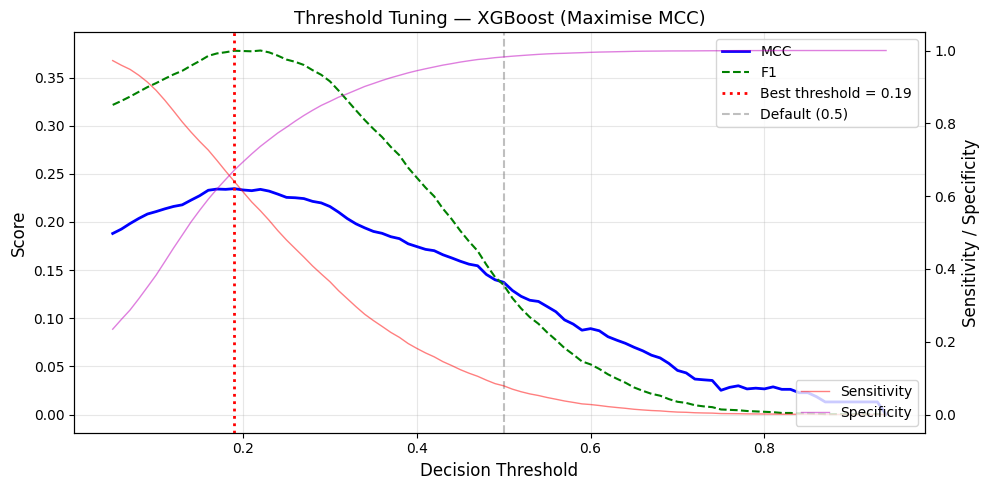

In [58]:
# ── 4.3 Threshold Tuning — Maximise MCC ──────────────────────────────────────
#
# The default threshold (0.5) optimises accuracy, not balanced performance.
# We sweep thresholds on the held-out test set probabilities and select the
# threshold that maximises Matthews Correlation Coefficient (MCC), which
# balances all four quadrants of the confusion matrix.

y_test_prob = final_model.predict_proba(X_test)[:, 1]

thresh_range = np.arange(0.05, 0.95, 0.01)
mcc_scores = []
f1_scores  = []
sens_scores = []
spec_scores = []

for t in thresh_range:
    pred_t = (y_test_prob >= t).astype(int)
    mcc_scores.append(matthews_corrcoef(y_test, pred_t))
    f1_scores.append(f1_score(y_test, pred_t, zero_division=0))
    tn, fp, fn, tp = confusion_matrix(y_test, pred_t).ravel()
    sens_scores.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    spec_scores.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

best_mcc_idx = np.argmax(mcc_scores)
best_threshold = thresh_range[best_mcc_idx]
best_mcc = mcc_scores[best_mcc_idx]

print(f"Optimal threshold (max MCC): {best_threshold:.2f}")
print(f"  MCC at optimal:    {best_mcc:.4f}")
print(f"  Sensitivity:       {sens_scores[best_mcc_idx]:.4f}")
print(f"  Specificity:       {spec_scores[best_mcc_idx]:.4f}")

# ── Visualise threshold sweep ─────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(thresh_range, mcc_scores, 'b-', linewidth=2, label='MCC')
ax1.plot(thresh_range, f1_scores, 'g--', linewidth=1.5, label='F1')
ax1.axvline(best_threshold, color='red', linestyle=':', linewidth=2,
            label=f'Best threshold = {best_threshold:.2f}')
ax1.axvline(0.5, color='grey', linestyle='--', alpha=0.5, label='Default (0.5)')
ax1.set_xlabel('Decision Threshold', fontsize=12)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title(f'Threshold Tuning — {best_model_name} (Maximise MCC)', fontsize=13)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(thresh_range, sens_scores, 'r-', alpha=0.5, linewidth=1, label='Sensitivity')
ax2.plot(thresh_range, spec_scores, 'm-', alpha=0.5, linewidth=1, label='Specificity')
ax2.set_ylabel('Sensitivity / Specificity', fontsize=12)
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()


In [59]:
# ── 4.4 Final Test Evaluation ─────────────────────────────────────────────────
#
# Evaluate the best model at both default (0.5) and MCC-optimal thresholds
# on the 30% held-out test set that has NEVER been used for training or tuning.

def evaluate_model(y_true, y_pred, y_prob, label):
    """Full metric suite for a single model configuration."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    g_mean = np.sqrt(sens * spec)
    metrics = {
        'label':       label,
        'accuracy':    accuracy_score(y_true, y_pred),
        'auc':         roc_auc_score(y_true, y_prob),
        'mcc':         matthews_corrcoef(y_true, y_pred),
        'f1':          f1_score(y_true, y_pred),
        'g_mean':      g_mean,
        'sensitivity': sens,
        'specificity': spec,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
    }
    print(f"\n{'─'*55}")
    print(f"  {label}")
    print(f"{'─'*55}")
    print(f"  Accuracy:    {metrics['accuracy']:.4f}")
    print(f"  ROC-AUC:     {metrics['auc']:.4f}")
    print(f"  MCC:         {metrics['mcc']:.4f}")
    print(f"  F1:          {metrics['f1']:.4f}")
    print(f"  G-Mean:      {metrics['g_mean']:.4f}")
    print(f"  Sensitivity: {sens:.4f}  (recall on fatal/serious)")
    print(f"  Specificity: {spec:.4f}  (recall on slight)")
    print(f"  Confusion matrix:  TN={tn:,}  FP={fp:,}  |  FN={fn:,}  TP={tp:,}")
    return metrics

# Default threshold
y_pred_default = final_model.predict(X_test)
m_default = evaluate_model(y_test, y_pred_default, y_test_prob,
                           f'{best_model_name} — threshold=0.50')

# MCC-optimal threshold
y_pred_tuned = (y_test_prob >= best_threshold).astype(int)
m_tuned = evaluate_model(y_test, y_pred_tuned, y_test_prob,
                         f'{best_model_name} — threshold={best_threshold:.2f} (MCC-optimal)')

# ── Comparison table ──────────────────────────────────────────────────────────
comp_df = pd.DataFrame([m_default, m_tuned])[
    ['label', 'accuracy', 'auc', 'mcc', 'f1', 'g_mean', 'sensitivity', 'specificity']
]
print(f"\n{'='*65}")
print("  FINAL TEST SET COMPARISON")
print(f"{'='*65}")
print(comp_df.to_string(index=False))



───────────────────────────────────────────────────────
  XGBoost — threshold=0.50
───────────────────────────────────────────────────────
  Accuracy:    0.8395
  ROC-AUC:     0.7204
  MCC:         0.1373
  F1:          0.1345
  G-Mean:      0.2783
  Sensitivity: 0.0788  (recall on fatal/serious)
  Specificity: 0.9824  (recall on slight)
  Confusion matrix:  TN=25,740  FP=460  |  FN=4,534  TP=388

───────────────────────────────────────────────────────
  XGBoost — threshold=0.19 (MCC-optimal)
───────────────────────────────────────────────────────
  Accuracy:    0.6666
  ROC-AUC:     0.7204
  MCC:         0.2346
  F1:          0.3778
  G-Mean:      0.6557
  Sensitivity: 0.6402  (recall on fatal/serious)
  Specificity: 0.6715  (recall on slight)
  Confusion matrix:  TN=17,594  FP=8,606  |  FN=1,771  TP=3,151

  FINAL TEST SET COMPARISON
                                 label  accuracy      auc      mcc       f1   g_mean  sensitivity  specificity
              XGBoost — threshold=0.50  

SHAP Beeswarm Plot — feature impact on Fatal/Serious prediction


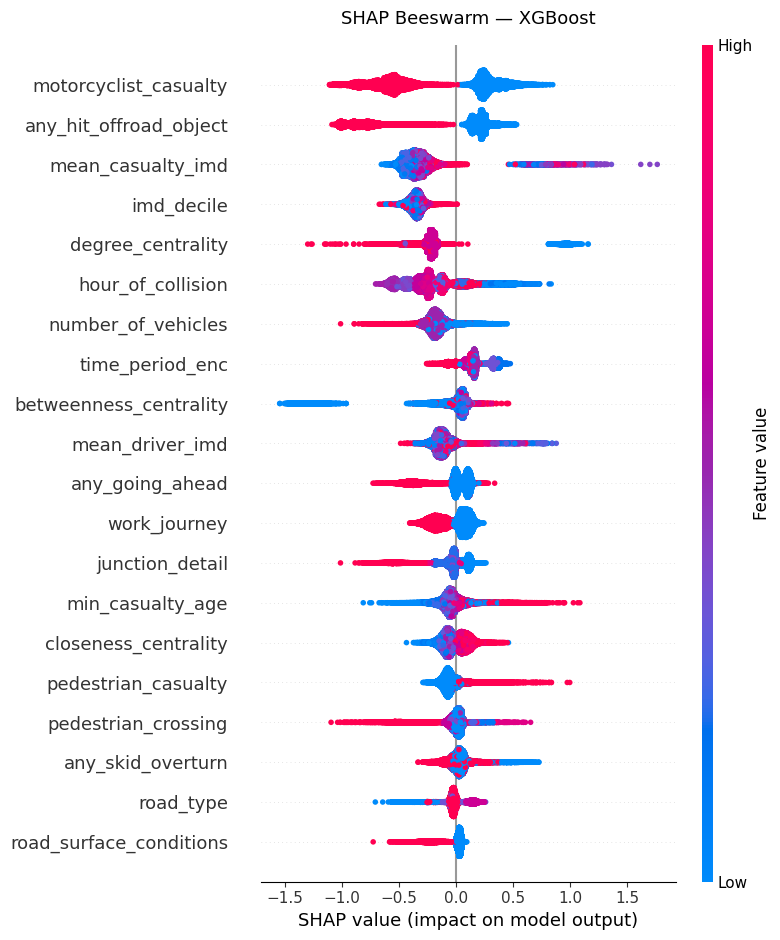


SHAP Feature Importance — mean |SHAP value|


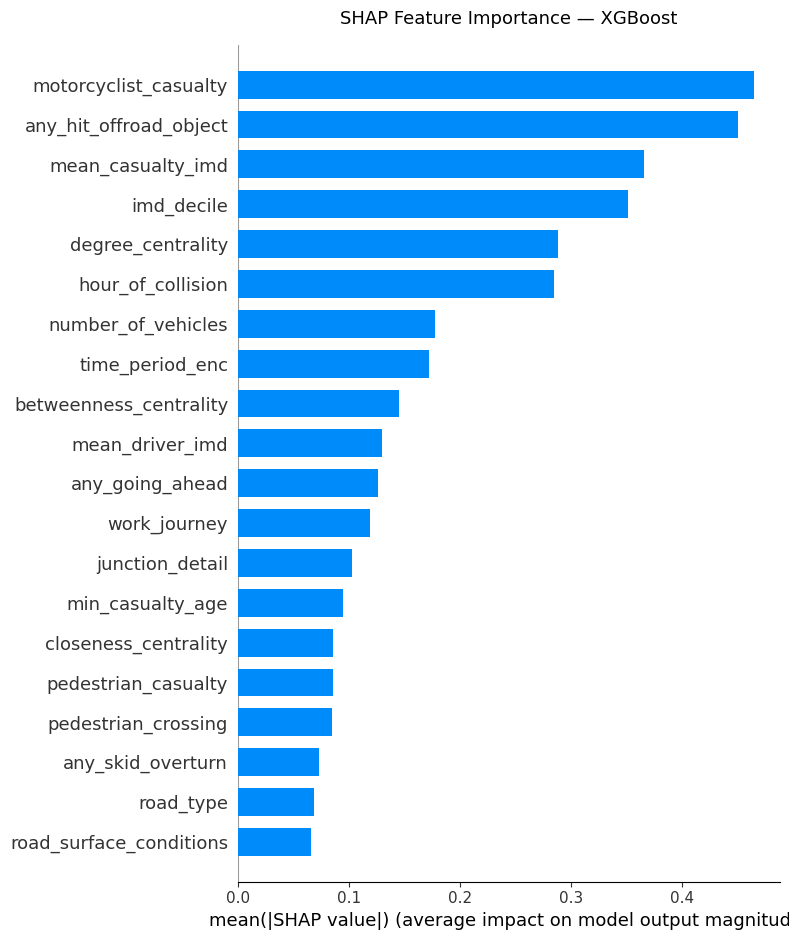


Top 15 features by mean |SHAP|:
               feature  mean_abs_shap
 motorcyclist_casualty       0.464920
any_hit_offroad_object       0.450559
     mean_casualty_imd       0.365263
            imd_decile       0.351205
     degree_centrality       0.288256
     hour_of_collision       0.284266
    number_of_vehicles       0.177211
       time_period_enc       0.171778
betweenness_centrality       0.144770
       mean_driver_imd       0.129410
       any_going_ahead       0.125895
          work_journey       0.118885
       junction_detail       0.102946
      min_casualty_age       0.094910
  closeness_centrality       0.086101

avg_speed_kph rank: #28/39 (mean |SHAP| = 0.0436)


In [60]:
# ── 4.5 SHAP Feature Importance & Beeswarm ───────────────────────────────────
#
# SHAP (SHapley Additive exPlanations) quantifies each feature's contribution
# to individual predictions. We use TreeExplainer for the best tree-based model.

import shap

# Compute SHAP values on test set
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

# For binary classifiers, shap_values may be a list [class_0, class_1]
# or a single array. Handle both cases.
if isinstance(shap_values, list):
    sv = shap_values[1]   # SHAP values for positive class (fatal/serious)
else:
    sv = shap_values

# ── SHAP Beeswarm Plot ───────────────────────────────────────────────────────
print("SHAP Beeswarm Plot — feature impact on Fatal/Serious prediction")
fig, ax = plt.subplots(figsize=(10, 10))
shap.summary_plot(sv, X_test, feature_names=feature_cols,
                  show=False, max_display=20)
plt.title(f'SHAP Beeswarm — {best_model_name}', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

# ── SHAP Feature Importance (mean |SHAP|) ────────────────────────────────────
print("\nSHAP Feature Importance — mean |SHAP value|")
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(sv, X_test, feature_names=feature_cols,
                  plot_type='bar', show=False, max_display=20)
plt.title(f'SHAP Feature Importance — {best_model_name}', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

# ── Top features table ────────────────────────────────────────────────────────
mean_shap = pd.DataFrame({
    'feature': feature_cols,
    'mean_abs_shap': np.abs(sv).mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False)

print(f"\nTop 15 features by mean |SHAP|:")
print(mean_shap.head(15).to_string(index=False))

# Check where avg_speed_kph ranks
speed_rank = mean_shap.reset_index(drop=True)
speed_row = speed_rank[speed_rank['feature'] == 'avg_speed_kph']
if len(speed_row) > 0:
    rank = speed_row.index[0] + 1
    print(f"\navg_speed_kph rank: #{rank}/{len(feature_cols)} "
          f"(mean |SHAP| = {speed_row['mean_abs_shap'].values[0]:.4f})")


In [66]:
gdf.groupby('motorcyclist_casualty')['severity_binary'].agg(['mean', 'count'])

,mean,count
motorcyclist_casualty,,
0,0.220095,49006
1,0.108451,60018


Computing permutation importance (MCC scoring, 10 repeats)...
This may take a few minutes.



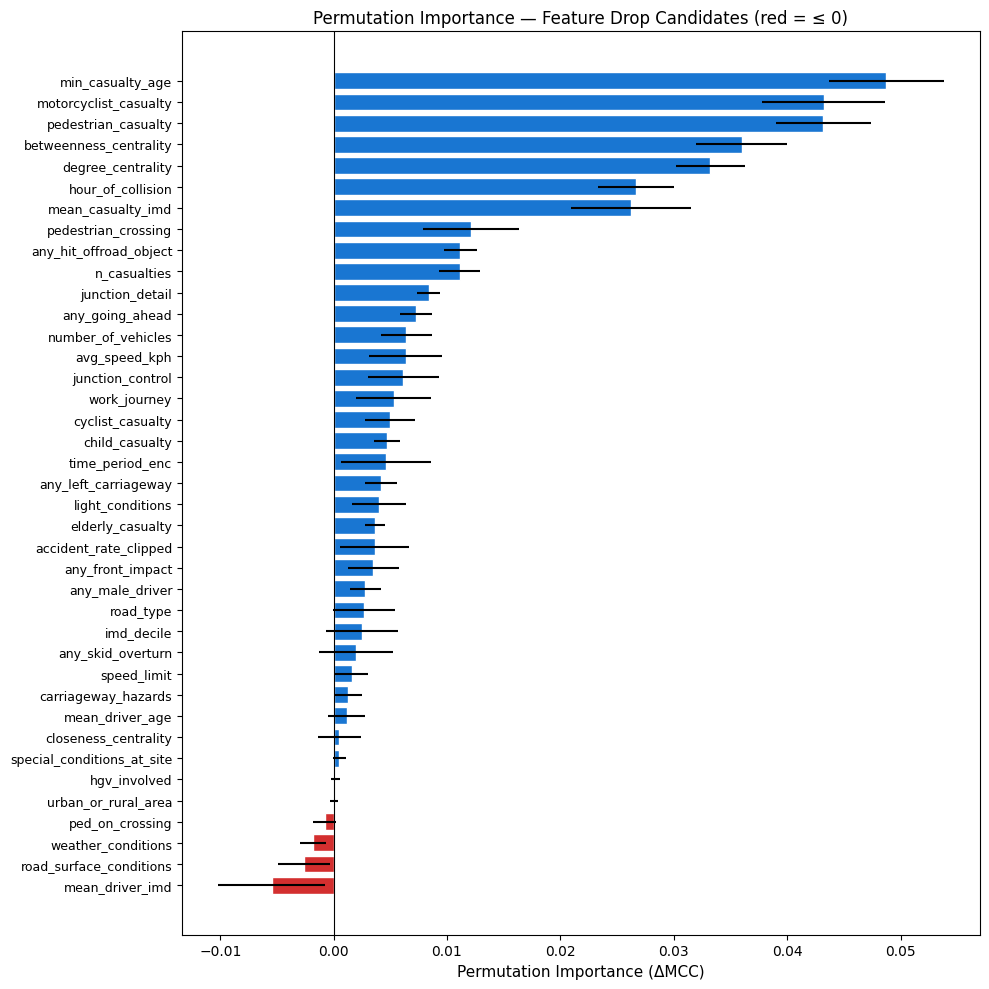


Drop candidates (perm importance ≤ 0): 4
  ped_on_crossing                      -0.00079 ± 0.00100
  weather_conditions                   -0.00179 ± 0.00115
  road_surface_conditions              -0.00262 ± 0.00230
  mean_driver_imd                      -0.00547 ± 0.00471

Marginal features (positive but < 1 std): 8
  road_type                            +0.00270 ± 0.00274
  imd_decile                           +0.00249 ± 0.00317
  any_skid_overturn                    +0.00196 ± 0.00327
  mean_driver_age                      +0.00115 ± 0.00162
  closeness_centrality                 +0.00052 ± 0.00187
  special_conditions_at_site           +0.00051 ± 0.00058
  hgv_involved                         +0.00017 ± 0.00044
  urban_or_rural_area                  +0.00006 ± 0.00034

Retained features: 35


In [61]:
# ── 4.6 Permutation Importance — Feature Drop Candidates ─────────────────────
#
# Permutation importance measures how much test-set performance degrades when
# a single feature is randomly shuffled. Unlike SHAP (which decomposes
# predictions), this directly measures predictive utility.
#
# Features with zero or negative permutation importance are candidates for
# removal — they add noise without improving discrimination.

from sklearn.inspection import permutation_importance

# Run on held-out test set with MCC as the scoring metric
# (aligns with our threshold-tuning objective)
print("Computing permutation importance (MCC scoring, 10 repeats)...")
print("This may take a few minutes.\n")

perm_result = permutation_importance(
    final_model, X_test, y_test,
    scoring=make_scorer(matthews_corrcoef),
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)

perm_df = pd.DataFrame({
    'feature':       feature_cols,
    'perm_imp_mean': perm_result.importances_mean,
    'perm_imp_std':  perm_result.importances_std,
}).sort_values('perm_imp_mean', ascending=False)

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#d32f2f' if v <= 0 else '#1976d2' for v in perm_df['perm_imp_mean']]
ax.barh(range(len(perm_df)), perm_df['perm_imp_mean'], 
        xerr=perm_df['perm_imp_std'], color=colors, edgecolor='white')
ax.set_yticks(range(len(perm_df)))
ax.set_yticklabels(perm_df['feature'], fontsize=9)
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.8, linestyle='-')
ax.set_xlabel('Permutation Importance (ΔMCC)', fontsize=11)
ax.set_title('Permutation Importance — Feature Drop Candidates (red = ≤ 0)', fontsize=12)
plt.tight_layout()
plt.show()

# ── Drop candidates: zero or negative importance ──────────────────────────────
drop_candidates = perm_df[perm_df['perm_imp_mean'] <= 0]['feature'].tolist()
marginal = perm_df[
    (perm_df['perm_imp_mean'] > 0) & 
    (perm_df['perm_imp_mean'] < perm_df['perm_imp_std'])
]['feature'].tolist()

print(f"\nDrop candidates (perm importance ≤ 0): {len(drop_candidates)}")
for f in drop_candidates:
    row = perm_df[perm_df['feature'] == f].iloc[0]
    print(f"  {f:<35s}  {row['perm_imp_mean']:+.5f} ± {row['perm_imp_std']:.5f}")

print(f"\nMarginal features (positive but < 1 std): {len(marginal)}")
for f in marginal:
    row = perm_df[perm_df['feature'] == f].iloc[0]
    print(f"  {f:<35s}  {row['perm_imp_mean']:+.5f} ± {row['perm_imp_std']:.5f}")

print(f"\nRetained features: {len(feature_cols) - len(drop_candidates)}")


Computing SHAP interaction values on 4,000 samples...
(This may take 5-10 minutes for XGBoost)

Top 20 SHAP interaction pairs:
Feature A                      Feature B                        |Interact|
───────────────────────────────────────────────────────────────────────────
hour_of_collision              time_period_enc                     0.25753
any_skid_overturn              any_hit_offroad_object              0.08434
betweenness_centrality         degree_centrality                   0.08384
number_of_vehicles             motorcyclist_casualty               0.05418
motorcyclist_casualty          cyclist_casualty                    0.05395
any_hit_offroad_object         any_going_ahead                     0.04759
pedestrian_casualty            motorcyclist_casualty               0.04072
mean_casualty_imd              n_casualties                        0.03610
any_male_driver                motorcyclist_casualty               0.03079
any_hit_offroad_object         motorcyclist_cas

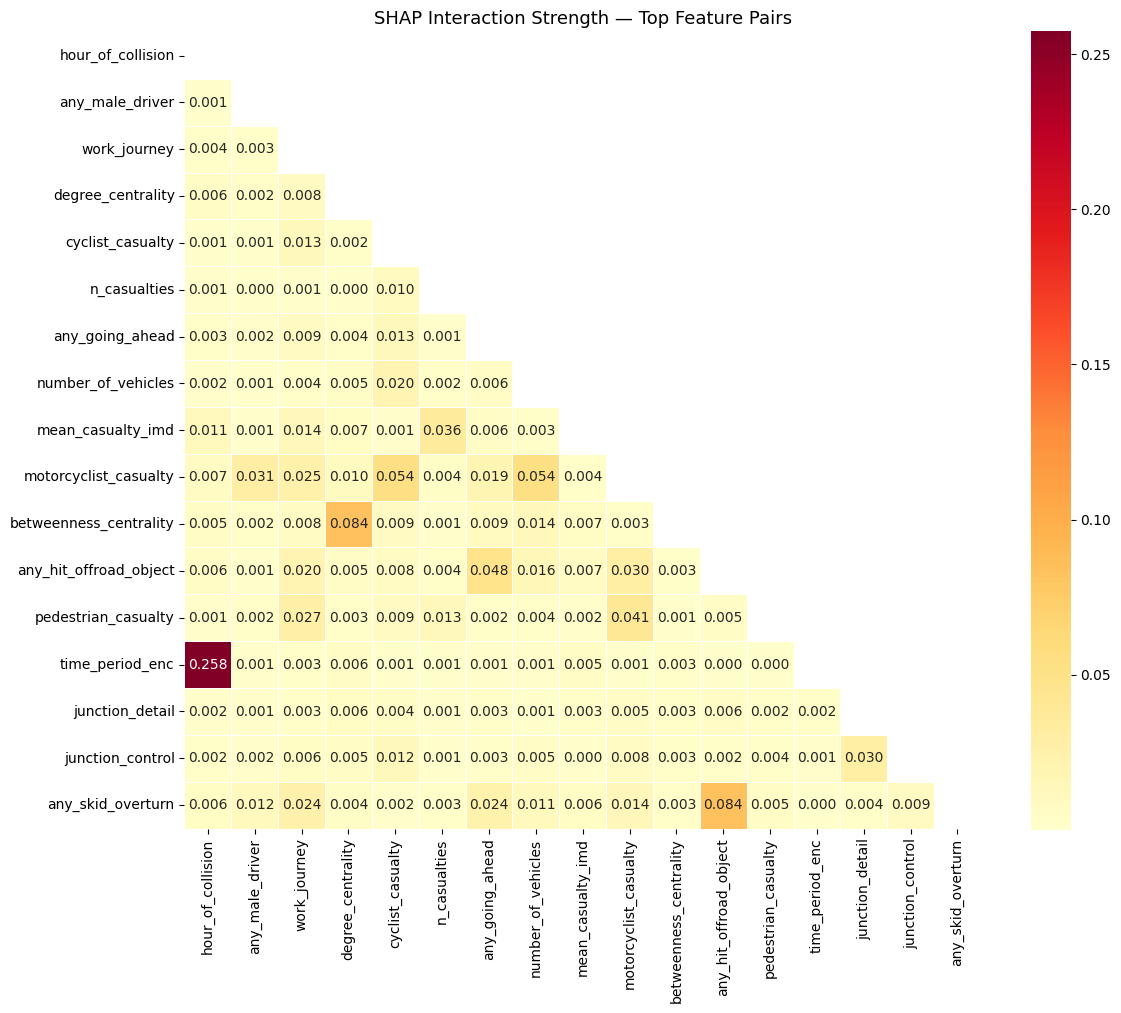

In [63]:
# ── 4.7 SHAP Interaction Values — Identifying Feature Synergies ──────────────
#
# SHAP interaction values decompose each prediction into main effects + 
# pairwise interactions. A large |interaction value| between features A and B
# means they have a synergistic (or antagonistic) effect on severity prediction
# that neither captures alone.
#
# We focus on domain-motivated interaction hypotheses:
#   H1: speed_limit × motorcycle_involved   (speed amplifies vulnerable user risk)
#   H2: speed_limit × pedestrian_casualty   (pedestrian fatality risk scales with speed)
#   H3: hour_of_collision × light_conditions (darkness effect varies by time)
#   H4: betweenness_centrality × aadf_log   (network bottleneck × traffic volume)
#   H5: mean_casualty_imd × pedestrian_casualty (deprivation × vulnerability)
#   H6: avg_speed_kph × speed_limit          (actual vs posted speed discrepancy)
#   H7: cycle_involved × speed_limit         (cyclist severity scales with speed)

# ── Approach 1: SHAP interaction values (full matrix) ─────────────────────────
# NOTE: TreeExplainer interaction values are O(n × features²) — we subsample
# to keep runtime manageable.

import shap

SAMPLE_N = 4000
np.random.seed(42)
sample_idx = np.random.choice(len(X_test), size=min(SAMPLE_N, len(X_test)), replace=False)
X_sample = X_test.iloc[sample_idx]

print(f"Computing SHAP interaction values on {len(X_sample):,} samples...")
print("(This may take 5-10 minutes for XGBoost)\n")

explainer = shap.TreeExplainer(final_model)
shap_interaction = explainer.shap_interaction_values(X_sample)

# For binary classifier, may return list — take positive class
if isinstance(shap_interaction, list):
    shap_interaction = shap_interaction[1]

# ── Aggregate interaction strength ────────────────────────────────────────────
# Mean absolute interaction value for each feature pair
n_features = len(feature_cols)
interact_strength = np.zeros((n_features, n_features))
for i in range(n_features):
    for j in range(n_features):
        interact_strength[i, j] = np.abs(shap_interaction[:, i, j]).mean()

interact_df = pd.DataFrame(interact_strength, 
                            index=feature_cols, columns=feature_cols)

# ── Top 20 interaction pairs ──────────────────────────────────────────────────
pairs = []
for i in range(n_features):
    for j in range(i+1, n_features):
        pairs.append({
            'feature_a': feature_cols[i],
            'feature_b': feature_cols[j],
            'mean_abs_interaction': interact_strength[i, j],
        })

pairs_df = pd.DataFrame(pairs).sort_values('mean_abs_interaction', ascending=False)

print("Top 20 SHAP interaction pairs:")
print(f"{'Feature A':<30s} {'Feature B':<30s} {'|Interact|':>12s}")
print("─" * 75)
for _, row in pairs_df.head(20).iterrows():
    print(f"{row['feature_a']:<30s} {row['feature_b']:<30s} "
          f"{row['mean_abs_interaction']:12.5f}")

# ── Heatmap of top interacting features ───────────────────────────────────────
# Show only features involved in the top 20 interactions
top_features = list(set(
    pairs_df.head(15)['feature_a'].tolist() + 
    pairs_df.head(15)['feature_b'].tolist()
))
top_interact = interact_df.loc[top_features, top_features]

fig, ax = plt.subplots(figsize=(12, 10))
import seaborn as sns
mask = np.triu(np.ones_like(top_interact, dtype=bool))
sns.heatmap(top_interact, mask=mask, cmap='YlOrRd', annot=True, fmt='.3f',
            linewidths=0.5, ax=ax, square=True)
ax.set_title('SHAP Interaction Strength — Top Feature Pairs', fontsize=13)
plt.tight_layout()
plt.show()


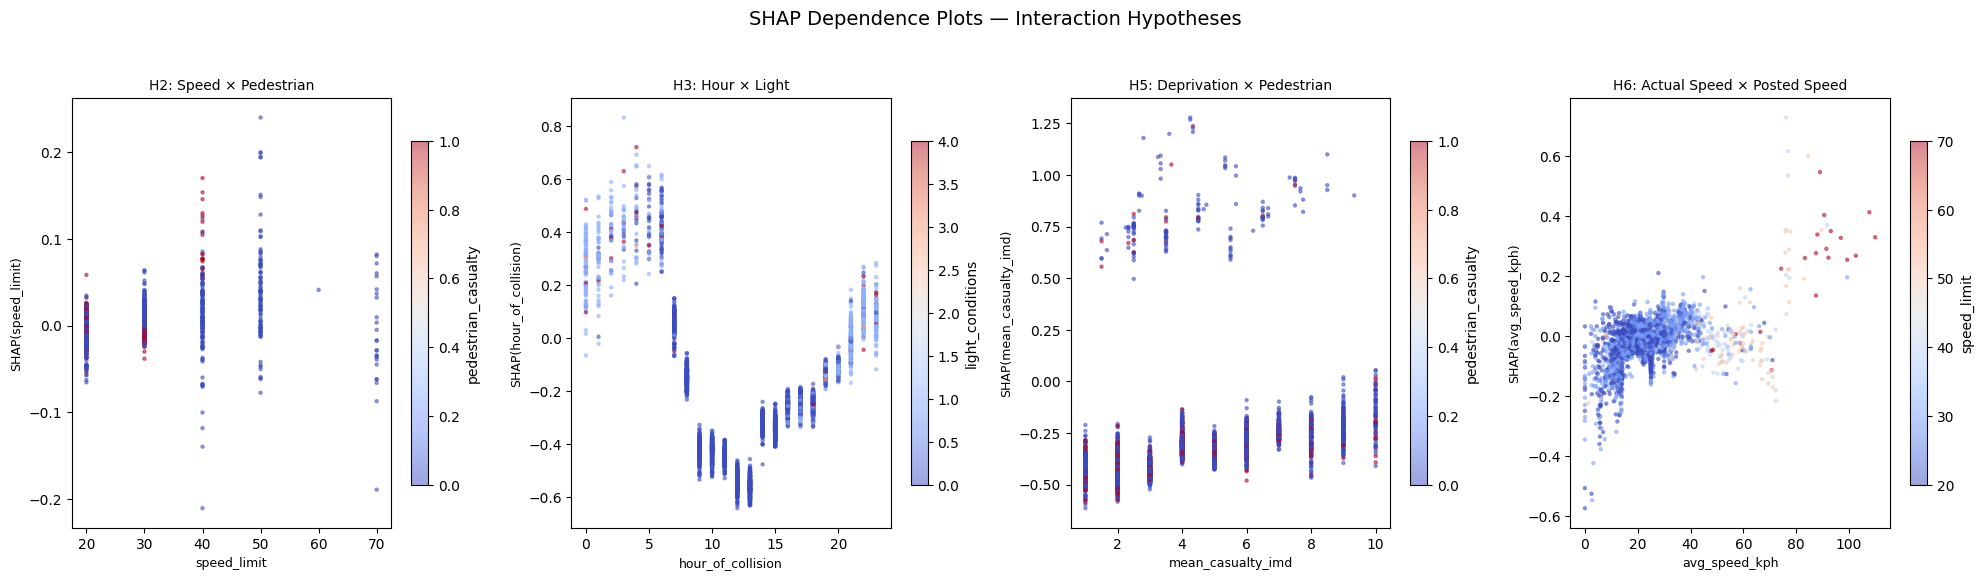

In [64]:
# ── 4.7b SHAP Dependence Plots — Domain Hypotheses ───────────────────────────
#
# Visualise how the SHAP value of one feature changes as a function of
# another feature. Colour encodes the interaction partner.

# Recompute standard SHAP values on the same sample for consistent indexing
sv_sample = explainer.shap_values(X_sample)
if isinstance(sv_sample, list):
    sv_sample = sv_sample[1]

hypotheses = [
    ('speed_limit', 'motorcycle_involved',   'H1: Speed × Motorcycle'),
    ('speed_limit', 'pedestrian_casualty',   'H2: Speed × Pedestrian'),
    ('hour_of_collision', 'light_conditions', 'H3: Hour × Light'),
    ('betweenness_centrality', 'aadf_log',   'H4: Centrality × Traffic'),
    ('mean_casualty_imd', 'pedestrian_casualty', 'H5: Deprivation × Pedestrian'),
    ('avg_speed_kph', 'speed_limit',          'H6: Actual Speed × Posted Speed'),
    ('cycle_involved', 'speed_limit',         'H7: Cyclist × Speed'),
]

# Filter to hypotheses where both features exist
hypotheses = [(a, b, title) for a, b, title in hypotheses 
              if a in feature_cols and b in feature_cols]

n_plots = len(hypotheses)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, (feat_a, feat_b, title) in enumerate(hypotheses):
    ax = axes[idx]
    col_a = feature_cols.index(feat_a)
    col_b = feature_cols.index(feat_b)
    
    sc = ax.scatter(
        X_sample[feat_a], sv_sample[:, col_a],
        c=X_sample[feat_b], cmap='coolwarm', s=5, alpha=0.5
    )
    ax.set_xlabel(feat_a, fontsize=9)
    ax.set_ylabel(f'SHAP({feat_a})', fontsize=9)
    ax.set_title(title, fontsize=10)
    plt.colorbar(sc, ax=ax, label=feat_b, shrink=0.8)

# Hide unused axes
for idx in range(n_plots, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('SHAP Dependence Plots — Interaction Hypotheses', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [65]:
# ── 4.8 Feature Engineering — Interaction Terms & Ablation ────────────────────
#
# Based on SHAP interaction analysis, we engineer candidate interaction terms
# and test whether they improve predictive performance.
#
# Strategy:
#   1. Drop features with zero/negative permutation importance
#   2. Add top interaction terms (from 4.7)
#   3. Compare: Original vs Pruned vs Pruned+Interactions
#
# Each variant uses the same pipeline: SMOTE → XGBoost (best params) →
# MCC-optimal threshold on test set.

from copy import deepcopy

# ── Define feature sets ───────────────────────────────────────────────────────

# Original
features_original = feature_cols.copy()

# Pruned: remove zero/negative permutation importance features
features_pruned = [f for f in feature_cols if f not in drop_candidates]

# Pruned + Interactions: add domain-motivated interaction terms
# (we'll engineer these from the top SHAP interaction pairs + domain hypotheses)
interaction_terms = {
    'speed_x_motorcycle':    ('speed_limit', 'motorcycle_involved'),
    'speed_x_pedestrian':    ('speed_limit', 'pedestrian_casualty'),
    'speed_x_cyclist':       ('speed_limit', 'cycle_involved'),
    'centrality_x_traffic':  ('betweenness_centrality', 'aadf_log'),
    'deprivation_x_ped':     ('mean_casualty_imd', 'pedestrian_casualty'),
    'hour_x_light':          ('hour_of_collision', 'light_conditions'),
}

# Only create interactions where both constituent features survived pruning
valid_interactions = {}
for name, (a, b) in interaction_terms.items():
    if a in features_pruned and b in features_pruned:
        valid_interactions[name] = (a, b)
    else:
        print(f"  Skipping {name}: constituent feature was pruned")

# Engineer interaction columns in model_df
for name, (a, b) in valid_interactions.items():
    model_df[name] = model_df[a] * model_df[b]

features_pruned_interact = features_pruned + list(valid_interactions.keys())

print(f"Feature set comparison:")
print(f"  Original:             {len(features_original)} features")
print(f"  Pruned:               {len(features_pruned)} features (dropped {len(drop_candidates)})")
print(f"  Pruned + Interactions: {len(features_pruned_interact)} features "
      f"(+{len(valid_interactions)} interactions)")

# ── Evaluate all three variants ───────────────────────────────────────────────

results_ablation = []

for label, cols in [
    ('Original (43 features)', features_original),
    (f'Pruned ({len(features_pruned)} features)', features_pruned),
    (f'Pruned + Interactions ({len(features_pruned_interact)} features)', 
     features_pruned_interact),
]:
    # Rebuild matrices (model_df already has interaction columns)
    X_abl = model_df[cols]
    y_abl = model_df['severity_binary']
    
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_abl, y_abl, test_size=0.3, random_state=42, stratify=y_abl
    )
    
    sm = SMOTE(random_state=42)
    X_tr_sm, y_tr_sm = sm.fit_resample(X_tr, y_tr)
    
    # Use best XGBoost params from CV
    clean_params = {k.replace('model__', ''): v 
                    for k, v in cv_results['XGBoost']['best_params'][-1].items()}
    model_abl = XGBClassifier(
        random_state=42, eval_metric='logloss', verbosity=0,
        n_jobs=-1, tree_method='hist', **clean_params
    )
    model_abl.fit(X_tr_sm, y_tr_sm)
    
    prob = model_abl.predict_proba(X_te)[:, 1]
    
    # Find MCC-optimal threshold
    best_t, best_mcc_val = 0.5, 0
    for t in np.arange(0.1, 0.9, 0.01):
        pred_t = (prob >= t).astype(int)
        mcc_t = matthews_corrcoef(y_te, pred_t)
        if mcc_t > best_mcc_val:
            best_mcc_val = mcc_t
            best_t = t
    
    pred = (prob >= best_t).astype(int)
    auc = roc_auc_score(y_te, prob)
    mcc = matthews_corrcoef(y_te, pred)
    tn, fp, fn, tp = confusion_matrix(y_te, pred).ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    g_mean = np.sqrt(sens * spec)
    
    results_ablation.append({
        'Model': label, 'Features': len(cols),
        'Threshold': f'{best_t:.2f}',
        'AUC': round(auc, 4), 'MCC': round(mcc, 4),
        'G-Mean': round(g_mean, 4),
        'Sensitivity': round(sens, 4), 'Specificity': round(spec, 4),
    })
    
    print(f"\n{label}")
    print(f"  Threshold: {best_t:.2f}  AUC: {auc:.4f}  MCC: {mcc:.4f}  "
          f"Sens: {sens:.4f}  Spec: {spec:.4f}  G-Mean: {g_mean:.4f}")

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print("  FEATURE ABLATION + INTERACTION COMPARISON")
print(f"{'='*70}")
ablation_df = pd.DataFrame(results_ablation)
print(ablation_df.to_string(index=False))


  Skipping speed_x_motorcycle: constituent feature was pruned
  Skipping speed_x_cyclist: constituent feature was pruned
  Skipping centrality_x_traffic: constituent feature was pruned
Feature set comparison:
  Original:             39 features
  Pruned:               35 features (dropped 4)
  Pruned + Interactions: 38 features (+3 interactions)

Original (43 features)
  Threshold: 0.19  AUC: 0.7204  MCC: 0.2346  Sens: 0.6402  Spec: 0.6715  G-Mean: 0.6557

Pruned (35 features)
  Threshold: 0.24  AUC: 0.7208  MCC: 0.2357  Sens: 0.5205  Spec: 0.7686  G-Mean: 0.6325

Pruned + Interactions (38 features)
  Threshold: 0.20  AUC: 0.7165  MCC: 0.2301  Sens: 0.6231  Spec: 0.6809  G-Mean: 0.6514

  FEATURE ABLATION + INTERACTION COMPARISON
                              Model  Features Threshold    AUC    MCC  G-Mean  Sensitivity  Specificity
             Original (43 features)        39      0.19 0.7204 0.2346  0.6557       0.6402       0.6715
               Pruned (35 features)        35      0

---
## 5. Results and Discussion

*[~420 words — interpret findings, reference figures, link back to research question]*




---
## 6. Conclusion

*[~130 words — summarise, reflect, limitations, future work]*



---
## 7. References

- Bíl, M., Andrášik, R. & Janoška, Z. (2013). Identification of hazardous road locations of traffic accidents. *Accident Analysis & Prevention*, 60, 47–55. https://doi.org/10.1016/j.aap.2013.07.018
- Derrible, S. & Kennedy, C. (2011). Applications of graph theory and network science to transit network design. *Transport Reviews*, 31(4), 495–519. https://doi.org/10.1080/01441647.2010.543709
- Lundberg, S.M. & Lee, S.I. (2017). A unified approach to interpreting model predictions. *Advances in Neural Information Processing Systems*, 30.
- Ribeiro, M.T., Singh, S. & Guestrin, C. (2016). "Why should I trust you?": Explaining the predictions of any classifier. *KDD 2016*. https://doi.org/10.1145/2939672.2939778
- Xie, Z. & Yan, J. (2008). Kernel density estimation of traffic accidents in a network space. *Computers, Environment and Urban Systems*, 32(5), 396–406. https://doi.org/10.1016/j.compenvurbsys.2008.05.001
- *[Add further references as needed — aim for 6–8 total]*